# Headline

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download

In [37]:
!pip install -U vnstock
!pip install optuna

## Import

In [38]:
# 1. Thư viện chuẩn & Cảnh báo hệ thống
import math
import time
import warnings
from abc import ABC, abstractmethod

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)

# 2. Xử lý dữ liệu & Trực quan hóa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from vnstock import *

# 3. Toán học, Xử lý tín hiệu & Khoảng cách (SciPy)
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.fft import rfft, rfftfreq
from scipy.spatial.distance import squareform
from scipy.stats import entropy, spearmanr

# 4. Thống kê & Phân tích chuỗi thời gian (Statsmodels)
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.stattools import acf, adfuller, bds, grangercausalitytests, kpss, pacf

# 5. Machine Learning (Scikit-learn)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    mean_squared_error,
    precision_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split

# 6. Boosting & Tối ưu hóa siêu tham số
import optuna
import xgboost as xgb


from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# Data Input

In [39]:
# =====================================================================
# 1. CẤU HÌNH THAM SỐ TOÀN CỤC (SINGLE ASSET CONFIGURATION)
# =====================================================================
# Tập trung vào 1 mã duy nhất để đào sâu Feature Engineering
SYMBOL = 'DIG'

START_DATE = '2018-01-01'
END_DATE = '2026-06-01'
DATA_SOURCE = 'KBS'  # Nguồn hỗ trợ phổ biến: 'KBS', 'VCI', 'TCBS'

# =====================================================================
# 2. HÀM TỔNG HỢP VI CẤU TRÚC TỪ INTRADAY SANG DAILY SUMMARY
# =====================================================================
def extract_daily_microstructure(df_intraday: pd.DataFrame) -> pd.DataFrame:
    """
    Tổng hợp các chỉ số vi cấu trúc từ dữ liệu nội phiên (Intraday)
    thành các biến EOD Epsilon-Causal phục vụ Model.
    """
    if df_intraday.empty:
        return pd.DataFrame()

    df = df_intraday.copy()
    df['date'] = pd.to_datetime(df['time']).dt.date

    # 1. Giả lập / Ước tính Order Flow Imbalance (OFI) & VPIN từ nến nội phiên
    price_diff = df['close'].diff().fillna(0)

    # Giả định: Giá tăng -> Khớp mua chủ động | Giá giảm -> Khớp bán chủ động
    buy_vol = np.where(price_diff >= 0, df['volume'], 0)
    sell_vol = np.where(price_diff < 0, df['volume'], 0)
    df['order_imbalance'] = buy_vol - sell_vol

    # 2. Tổng hợp theo từng ngày
    daily_agg = df.groupby('date').agg(
        intraday_ofi_mean=('order_imbalance', 'mean'),
        intraday_ofi_std=('order_imbalance', 'std'),
        intraday_ofi_sum=('order_imbalance', 'sum'),
        intraday_vol_sum=('volume', 'sum'),
        intraday_tick_count=('volume', 'count'),
        intraday_high=('high', 'max'),
        intraday_low=('low', 'min')
    ).reset_index()

    # VPIN Proxy (Xác suất độc hại dòng lệnh)
    daily_agg['daily_vpin'] = daily_agg['intraday_ofi_sum'].abs() / (daily_agg['intraday_vol_sum'] + 1e-8)
    daily_agg['intraday_ofi_std'] = daily_agg['intraday_ofi_std'].fillna(0)

    daily_agg.rename(columns={'date': 'time'}, inplace=True)
    daily_agg['time'] = pd.to_datetime(daily_agg['time'])
    return daily_agg

# =====================================================================
# 3. PIPELINE NẠP DỮ LIỆU KẾT HỢP (DAILY + MICROSTRUCTURE)
# =====================================================================
# =====================================================================
# PIPELINE NẠP DỮ LIỆU KẾT HỢP (DIG + VN-INDEX EXOGENOUS)
# =====================================================================
class AssetAndMarketLoader:
    def __init__(self, symbol: str, benchmark_symbol: str, start_date: str, end_date: str, source: str = 'KBS'):
        self.symbol = symbol
        self.benchmark_symbol = benchmark_symbol
        self.start_date = start_date
        self.end_date = end_date
        self.source = source

    def fetch_data(self) -> pd.DataFrame:
        print(f"[*] Đang tải dữ liệu cổ phiếu cơ sở ({self.symbol}) và thị trường ({self.benchmark_symbol})...")
        quote_asset = Quote(symbol=self.symbol, source=self.source)
        quote_mkt = Quote(symbol=self.benchmark_symbol, source=self.source)

        # 1. Tải Daily OHLCV của cổ phiếu mục tiêu
        df_asset = quote_asset.history(start=self.start_date, end=self.end_date, interval='1D')
        if df_asset is None or df_asset.empty:
            raise ValueError(f"Không có dữ liệu Daily cho mã {self.symbol}")
        df_asset['time'] = pd.to_datetime(df_asset['time'])
        df_asset.sort_values(by='time', inplace=True)

        # 2. Tải Daily OHLCV của VN-Index
        print(f"  -> Đang tải dữ liệu Benchmark: {self.benchmark_symbol}...")
        df_mkt = quote_mkt.history(start=self.start_date, end=self.end_date, interval='1D')
        if df_mkt is None or df_mkt.empty:
            # Fallback nếu nguồn KBS không có index, chuyển sang nguồn khác hoặc thử VCI
            print("  [!] Thử nguồn VCI cho chỉ số VNINDEX...")
            quote_mkt_fallback = Quote(symbol=self.benchmark_symbol, source='VCI')
            df_mkt = quote_mkt_fallback.history(start=self.start_date, end=self.end_date, interval='1D')

        df_mkt['time'] = pd.to_datetime(df_mkt['time'])
        df_mkt.sort_values(by='time', inplace=True)

        # Trích xuất các biến cơ bản của Market Benchmark
        df_mkt = df_mkt[['time', 'close', 'volume', 'high', 'low']].rename(columns={
            'close': 'mkt_close',
            'volume': 'mkt_volume',
            'high': 'mkt_high',
            'low': 'mkt_low'
        })
        df_mkt['mkt_return'] = np.log(df_mkt['mkt_close'] / df_mkt['mkt_close'].shift(1))

        # 3. Hợp nhất (Inner Join) để bảo đảm lịch giao dịch đồng nhất
        df_merged = pd.merge(df_asset, df_mkt, on='time', how='inner')
        df_merged.sort_values(by='time', inplace=True)
        print(f"  ✓ Đã đồng bộ thành công: {len(df_merged)} phiên chung giữa {self.symbol} và {self.benchmark_symbol}.")
        return df_merged

# =====================================================================
# 4. THỰC THI NẠP DỮ LIỆU & LƯU TRỮ
# =====================================================================
loader = AssetAndMarketLoader(
    symbol=SYMBOL,
    benchmark_symbol='VNINDEX',
    start_date=START_DATE,
    end_date=END_DATE,
    source=DATA_SOURCE
)
df_raw = loader.fetch_data()

# Điền khuyết (Forward Fill) cho các biến vi cấu trúc nếu có ngày không khớp Intraday
micro_cols = [c for c in df_raw.columns if 'intraday' in c or 'vpin' in c]
if micro_cols:
    df_raw[micro_cols] = df_raw[micro_cols].fillna(method='ffill').fillna(0)

df_raw.to_csv('df_raw.csv', index=False)

[*] Đang tải dữ liệu cổ phiếu cơ sở (DIG) và thị trường (VNINDEX)...


2026-09-04 10:26:14 - vnai.beam.patching - WARNING - ⚠️ Phiên bản cộng đồng: Dữ liệu OHLCV (1D) giới hạn tối đa 8 năm. Nâng cấp gói tài trợ để mở rộng giới hạn cho phân tích chuyên nghiệp: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program


  -> Đang tải dữ liệu Benchmark: VNINDEX...


2026-09-04 10:26:16 - vnai.beam.patching - WARNING - ⚠️ Phiên bản cộng đồng: Dữ liệu OHLCV (1D) giới hạn tối đa 8 năm. Nâng cấp gói tài trợ để mở rộng giới hạn cho phân tích chuyên nghiệp: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program
⚠️ Community edition: OHLCV data (1D) limited to 8 years. Upgrade your plan to unlock full data limits for professional use: https://vnstocks.com/insiders-program


  ✓ Đã đồng bộ thành công: 1996 phiên chung giữa DIG và VNINDEX.


## Data Visualization

In [40]:
# =====================================================================
# 5. HIỂN THỊ KIỂM TOÁN VẬT LÝ VÀ CHẨN ĐOÁN NANs ĐẦU VÀO
# =====================================================================
print("\n" + "=" * 80)
print(f"TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):")
print(f"- Số dòng tổng cộng      : {len(df_raw):,}")
print(f"- Mã cổ phiếu            : {SYMBOL}")
print(f"- Khung thời gian        : Từ {df_raw['time'].min().date()} đến {df_raw['time'].max().date()}")
print(f"- Tổng giá trị khuyết NaN: {df_raw.isna().sum().sum()}")
print("=" * 80)

# Hiển thị danh sách các cột hiện có để xác nhận Vi cấu trúc đã được gộp thành công
print(f"\n[Các cột dữ liệu hiện có]:\n{df_raw.columns.tolist()}\n")

# Hiển thị cấu trúc mẫu
display(df_raw.head())
display(df_raw.tail())

print("\n" * 2)
print(f"No. NaN values: {df_raw.isna().sum().sum()}")
if df_raw.isna().sum().sum() > 0:
    display(df_raw.isna().sum()[df_raw.isna().sum() > 0])
else:
    print("Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!")


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 1,996
- Mã cổ phiếu            : DIG
- Khung thời gian        : Từ 2018-06-04 đến 2026-06-01
- Tổng giá trị khuyết NaN: 1

[Các cột dữ liệu hiện có]:
['time', 'open', 'high', 'low', 'close', 'volume', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,time,open,high,low,close,volume,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
0,2018-06-04 07:00:00,9.00,9.56,9.00,9.37,1439470,1013.78,146895440,1013.78,992.01,NaN
1,2018-06-05 07:00:00,9.23,9.65,9.23,9.65,1452440,1022.74,173096680,1025.26,1011.59,0.008799
2,2018-06-06 07:00:00,9.70,9.90,9.46,9.83,1273280,1034.50,147456500,1034.50,1012.98,0.011433
3,2018-06-07 07:00:00,9.70,9.79,9.46,9.51,1276620,1036.69,151829230,1043.71,1030.79,0.002115
4,2018-06-08 07:00:00,9.51,9.51,9.30,9.37,675770,1039.01,124180340,1039.07,1026.94,0.002235


,time,open,high,low,close,volume,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
1991,2026-05-26 07:00:00,13.70,14.15,13.65,13.80,7859600,1884.18,598836621,1889.15,1876.32,-0.000981
1992,2026-05-27 07:00:00,13.85,13.90,13.75,13.75,3128400,1874.43,667675136,1889.87,1863.18,-0.005188
1993,2026-05-28 07:00:00,13.80,13.85,13.50,13.50,4324500,1863.67,602798527,1882.66,1857.25,-0.005757
1994,2026-05-29 07:00:00,13.45,13.55,13.05,13.05,5852300,1863.49,556018675,1873.17,1855.96,-0.000097
1995,2026-06-01 07:00:00,13.25,13.40,13.10,13.20,5152700,1844.54,431817093,1871.09,1841.39,-0.010221





No. NaN values: 1


,0
mkt_return,1


### làm sạch là loại bỏ NaN trong Return:

In [41]:
df_raw = df_raw.dropna()
df_raw.to_csv('df_raw.csv', index=False)

# =====================================================================
# 5. HIỂN THỊ KIỂM TOÁN VẬT LÝ VÀ CHẨN ĐOÁN NANs ĐẦU VÀO
# =====================================================================
print("\n" + "=" * 80)
print(f"TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):")
print(f"- Số dòng tổng cộng      : {len(df_raw):,}")
print(f"- Mã cổ phiếu            : {SYMBOL}")
print(f"- Khung thời gian        : Từ {df_raw['time'].min().date()} đến {df_raw['time'].max().date()}")
print(f"- Tổng giá trị khuyết NaN: {df_raw.isna().sum().sum()}")
print("=" * 80)

# Hiển thị danh sách các cột hiện có để xác nhận Vi cấu trúc đã được gộp thành công
print(f"\n[Các cột dữ liệu hiện có]:\n{df_raw.columns.tolist()}\n")

# Hiển thị cấu trúc mẫu
display(df_raw.head())
display(df_raw.tail())

print("\n" * 2)
print(f"No. NaN values: {df_raw.isna().sum().sum()}")
if df_raw.isna().sum().sum() > 0:
    display(df_raw.isna().sum()[df_raw.isna().sum() > 0])
else:
    print("Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!")


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 1,995
- Mã cổ phiếu            : DIG
- Khung thời gian        : Từ 2018-06-05 đến 2026-06-01
- Tổng giá trị khuyết NaN: 0

[Các cột dữ liệu hiện có]:
['time', 'open', 'high', 'low', 'close', 'volume', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,time,open,high,low,close,volume,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
1,2018-06-05 07:00:00,9.23,9.65,9.23,9.65,1452440,1022.74,173096680,1025.26,1011.59,0.008799
2,2018-06-06 07:00:00,9.70,9.90,9.46,9.83,1273280,1034.50,147456500,1034.50,1012.98,0.011433
3,2018-06-07 07:00:00,9.70,9.79,9.46,9.51,1276620,1036.69,151829230,1043.71,1030.79,0.002115
4,2018-06-08 07:00:00,9.51,9.51,9.30,9.37,675770,1039.01,124180340,1039.07,1026.94,0.002235
5,2018-06-11 07:00:00,9.14,9.35,8.77,9.10,1005130,1039.02,133836660,1045.60,1029.19,0.000010


,time,open,high,low,close,volume,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
1991,2026-05-26 07:00:00,13.70,14.15,13.65,13.80,7859600,1884.18,598836621,1889.15,1876.32,-0.000981
1992,2026-05-27 07:00:00,13.85,13.90,13.75,13.75,3128400,1874.43,667675136,1889.87,1863.18,-0.005188
1993,2026-05-28 07:00:00,13.80,13.85,13.50,13.50,4324500,1863.67,602798527,1882.66,1857.25,-0.005757
1994,2026-05-29 07:00:00,13.45,13.55,13.05,13.05,5852300,1863.49,556018675,1873.17,1855.96,-0.000097
1995,2026-06-01 07:00:00,13.25,13.40,13.10,13.20,5152700,1844.54,431817093,1871.09,1841.39,-0.010221





No. NaN values: 0
Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!


# Feature Engineering

## BƯỚC 1: XÁC LẬP BÀI TOÁN, KIỂM TOÁN VẬT LÝ VÀ CHUẨN HÓA TOPOLOGY DỮ LIỆU
Mục tiêu: Đảm bảo dữ liệu thô sạch hoàn toàn về mặt vật lý, xác lập không gian xác suất và tập thông tin $\mathcal{I}_t$.

In [42]:
# =====================================================================
# BƯỚC 1: XÁC LẬP BÀI TOÁN & CHUẨN HÓA TOPOLOGY ĐƠN TÀI SẢN (SINGLE-ASSET)
# Tích hợp nền tảng L2 Order Book Đa tầng (Multi-Level) & Chống Leakage
# =====================================================================

class Layer1DataIntegrity:
    @staticmethod
    def run_audit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        df = df.copy()
        initial_len = len(df)

        # 1. Deduplication & Chronological Sort
        if df.index.duplicated().any():
            df = df[~df.index.duplicated(keep='last')]
        df = df.sort_index()

        # 2. Geometric bounds audit (Kiểm toán biên hình học)
        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        # 3. Forward-Adjustment (Xử lý corporate actions tịnh tiến)
        if 'split_factor' not in df.columns:
            df['split_factor'] = 1.0
        if 'dividend' not in df.columns:
            df['dividend'] = 0.0

        daily_ret = ((df['close'] + df['dividend']) / (df['close'].shift(1) * df['split_factor'])) - 1.0
        df['close_adj'] = df['close'].iloc[0] * (1.0 + daily_ret).cumprod()
        df['close_adj'] = df['close_adj'].fillna(df['close'])

        ratio = df['close_adj'] / df['close']
        for col in ['open', 'high', 'low']:
            df[f'{col}_adj'] = df[col] * ratio

        # 4. [ZERO-VARIANCE DROP TRỰC TIẾP TỪ NGUỒN]
        # Loại bỏ các cột phẳng (đặc biệt là cột vi cấu trúc bị rỗng do API vnstock)
        dropped_zero_var = []
        for col in df.columns:
            if col not in ['split_factor', 'dividend', 'target_label']:
                if pd.api.types.is_numeric_dtype(df[col]):
                    if df[col].std() < 1e-8 or df[col].nunique() <= 1:
                        dropped_zero_var.append(col)

        if dropped_zero_var:
            df.drop(columns=dropped_zero_var, inplace=True)
            print(f"  [Layer1 Alert] Đã loại bỏ các cột Zero-Variance rỗng: {dropped_zero_var}")

        return df, {
            "initial_bars": initial_len,
            "clean_bars": len(df),
            "dropped_flat_cols": dropped_zero_var
        }

class Layer2MicrostructureTopologies:
    """
    Khai phá Topology: Mở rộng không gian trạng thái với dữ liệu vi cấu trúc.
    Xử lý dữ liệu Sổ lệnh L2 Đa tầng (Multi-level Order Book) lên đến N bước giá.
    """
    @staticmethod
    def compute(df: pd.DataFrame, max_depth_levels: int = 10) -> pd.DataFrame:
        df = df.copy()

        # 1. Topo Tiêu chuẩn (OHLCV)
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])

        # 2. Topo Vi cấu trúc (L2 Multi-Level Order Book)
        # Tự động quét số lượng tầng (depth) khả dụng trong dataset
        available_levels = []
        for i in range(1, max_depth_levels + 1):
            if f'bid_price_{i}' in df.columns and f'ask_price_{i}' in df.columns:
                available_levels.append(i)

        # Trạng thái A: Có dữ liệu Đa tầng (Multi-level L2)
        if len(available_levels) > 1:
            df['mid_price'] = (df['bid_price_1'] + df['ask_price_1']) / 2.0
            df['l2_spread'] = df['ask_price_1'] - df['bid_price_1']

            total_weighted_bid_size = np.zeros(len(df))
            total_weighted_ask_size = np.zeros(len(df))
            cross_weighted_bid_price = np.zeros(len(df))
            cross_weighted_ask_price = np.zeros(len(df))

            # Quét qua các tầng sổ lệnh, áp dụng Exponential Decay Weight
            # để giảm thiểu nhiễu từ các lệnh ảo (Spoofing) đặt ở giá xa
            for i in available_levels:
                decay_weight = np.exp(-(i - 1) * 0.5)

                b_size_w = df[f'bid_size_{i}'] * decay_weight
                a_size_w = df[f'ask_size_{i}'] * decay_weight

                total_weighted_bid_size += b_size_w
                total_weighted_ask_size += a_size_w

                cross_weighted_bid_price += df[f'bid_price_{i}'] * b_size_w
                cross_weighted_ask_price += df[f'ask_price_{i}'] * a_size_w

            imbalance_denominator = total_weighted_bid_size + total_weighted_ask_size + 1e-8

            # Tính Depth Order Book Imbalance (OBI đa tầng)
            df['order_imbalance_depth'] = (total_weighted_bid_size - total_weighted_ask_size) / imbalance_denominator

            # Tính Depth Micro-Price (Giao cắt chéo khối lượng 2 bên)
            # Thể hiện điểm cân bằng lực cung cầu thực sự của toàn bộ sổ lệnh
            df['micro_price_depth'] = (
                (cross_weighted_bid_price / (total_weighted_bid_size + 1e-8)) * total_weighted_ask_size +
                (cross_weighted_ask_price / (total_weighted_ask_size + 1e-8)) * total_weighted_bid_size
            ) / imbalance_denominator

            # Độ lệch định hướng vi mô sắc bén nhất
            df['micro_mid_deviation'] = df['micro_price_depth'] - df['mid_price']

        # Trạng thái B: Tương thích ngược - Chỉ có Top-of-book L1 (best_bid, best_ask)
        elif all(col in df.columns for col in ['best_bid', 'best_ask', 'bid_size', 'ask_size']):
            df['mid_price'] = (df['best_bid'] + df['best_ask']) / 2.0
            imbalance_denominator = df['bid_size'] + df['ask_size'] + 1e-8

            df['micro_price'] = (df['best_bid'] * df['ask_size'] + df['best_ask'] * df['bid_size']) / imbalance_denominator
            df['l2_spread'] = df['best_ask'] - df['best_bid']
            df['micro_mid_deviation'] = df['micro_price'] - df['mid_price']
            df['order_imbalance_depth'] = (df['bid_size'] - df['ask_size']) / imbalance_denominator

        return df


class Layer0TripleBarrier:
    """
    SỬ DỤNG TRIPLE BARRIER: Gắn nhãn phân loại theo rào cản chốt lời/cắt lỗ
    phụ thuộc vào biến động (Volatility Scaling).
    """
    @staticmethod
    def label(df: pd.DataFrame, h: int = 5, pt: float = 1.0, sl: float = 1.0, vol_span: int = 20) -> pd.DataFrame:
        df = df.copy()
        log_ret = df['log_return']

        # Biến động nội tại để co giãn rào cản
        sigma = log_ret.ewm(span=vol_span, min_periods=2).std().bfill()

        prices = df['close_adj'].values
        sigmas = sigma.values
        n = len(df)

        target = np.full(n, np.nan)
        ret_barrier = np.full(n, np.nan)
        touch_time = np.full(n, np.nan, dtype=object)

        for i in range(n - h):
            p0 = prices[i]

            # Bỏ qua nếu giá trị hiện tại bị khuyết
            if pd.isna(p0) or pd.isna(sigmas[i]):
                continue

            upper_barrier = p0 * (1.0 + pt * sigmas[i])
            lower_barrier = p0 * (1.0 - sl * sigmas[i])

            window_prices = prices[i + 1 : i + h + 1]
            hit_upper = np.where(window_prices >= upper_barrier)[0]
            hit_lower = np.where(window_prices <= lower_barrier)[0]

            first_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
            first_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf

            if first_upper < first_lower and first_upper < np.inf:
                target[i] = 1.0
                ret_barrier[i] = (window_prices[first_upper] / p0) - 1.0
                touch_time[i] = df.index[i + 1 + first_upper]
            elif first_lower < first_upper and first_lower < np.inf:
                target[i] = -1.0
                ret_barrier[i] = (window_prices[first_lower] / p0) - 1.0
                touch_time[i] = df.index[i + 1 + first_lower]
            else:
                target[i] = 0.0
                ret_barrier[i] = (window_prices[-1] / p0) - 1.0
                touch_time[i] = df.index[i + h]

        df['local_volatility'] = sigma
        df['target_label'] = target
        df['target_barrier_return'] = ret_barrier
        df['barrier_touch_time'] = touch_time
        return df

## BƯỚC 2: CHẨN ĐOÁN TOÀN DIỆN ĐẶC TÍNH QUÁ TRÌNH SINH DỮ LIỆU (DGP DIAGNOSTICS)
Mục tiêu: Sử dụng các kiểm định thống kê và kinh tế lượng vi cấu trúc trên mảng dữ liệu đầu vào (chưa dùng target) để thu thập bằng chứng thực nghiệm.

In [43]:
# =====================================================================
# CÁC LỚP CHẨN ĐOÁN (Single-Asset Data-Driven Diagnostics)
# =====================================================================

class Layer3DistributionalDiagnostics:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 30:
            return {"is_leptokurtic": False, "reject_normality": False}

        skew = float(stats.skew(r, bias=False))
        kurt = float(stats.kurtosis(r, fisher=False, bias=False))
        jb_stat, jb_p = stats.jarque_bera(r)

        return {
            "mean": float(np.mean(r)),
            "std": float(np.std(r, ddof=1)),
            "skewness": skew,
            "kurtosis": kurt,
            "is_leptokurtic": bool(kurt > 3.0),
            "jarque_bera_stat": float(jb_stat),
            "jarque_bera_pvalue": float(jb_p),
            "reject_normality": bool(jb_p < 0.05)
        }

class Layer4MemoryDependence:
    @staticmethod
    def compute_hurst_dfa(series: pd.Series) -> float:
        s = series.dropna().values
        y = np.cumsum(s - np.mean(s))
        n = len(y)
        if n < 40:
            return 0.5

        scales = np.floor(np.logspace(np.log10(10), np.log10(n // 4), num=15)).astype(int)
        scales = np.unique(scales)
        fluctuations = []

        for s_len in scales:
            num_segments = n // s_len
            segment_fluct = []
            for i in range(num_segments):
                seg = y[i * s_len : (i + 1) * s_len]
                x = np.arange(s_len)
                poly = np.polyfit(x, seg, 1)
                trend = np.polyval(poly, x)
                segment_fluct.append(np.sqrt(np.mean((seg - trend) ** 2)))
            fluctuations.append(np.mean(segment_fluct))

        poly_hurst = np.polyfit(np.log(scales), np.log(fluctuations), 1)
        return float(poly_hurst[0])

    @staticmethod
    def lo_mackinlay_vr(prices: pd.Series, k: int) -> dict:
        p = np.log(prices.dropna().values)
        t = len(p)
        if t <= k + 2:
            return {"vr": 1.0, "z_stat": 0.0, "p_value": 1.0}

        r1 = p[1:] - p[:-1]
        mu = (p[-1] - p[0]) / (t - 1)
        var_1 = np.sum((r1 - mu) ** 2) / (t - 2)

        rk = p[k:] - p[:-k]
        m = k * (t - k) * (1 - (k / (t - 1)))
        var_k = np.sum((rk - k * mu) ** 2) / m
        vr = var_k / var_1

        delta = np.zeros(k - 1)
        denom = (np.sum((r1 - mu) ** 2)) ** 2
        for j in range(1, k):
            num = np.sum(((r1[j:] - mu) ** 2) * ((r1[:-j] - mu) ** 2))
            delta[j - 1] = ((2.0 * (k - j) / k) ** 2) * (num / denom)

        phi_k = np.sum(delta)
        z_star = (vr - 1.0) / np.sqrt(phi_k) if phi_k > 0 else 0.0
        p_val = 2.0 * (1.0 - stats.norm.cdf(abs(z_star)))

        return {"vr": float(vr), "z_stat": float(z_star), "p_value": float(p_val)}

    @classmethod
    def multi_scale_memory(cls, prices: pd.Series, returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {
                "dynamic_lags": [1, 3, 5], "hurst": 0.5,
                "short_term_mean_reverting": False, "long_term_trending": False
            }

        max_lag = min(30, len(r) // 3)
        acf_vals = acf(r, nlags=max_lag, fft=True)
        conf_interval = 1.96 / np.sqrt(len(r))
        sig_lags = [i for i, val in enumerate(acf_vals[1:], 1) if abs(val) > conf_interval]

        if not sig_lags:
            sig_lags = [1, 3, 5]

        vr_short = cls.lo_mackinlay_vr(prices, k=3)
        vr_long = cls.lo_mackinlay_vr(prices, k=20)

        return {
            "dynamic_lags": sorted(list(set(sig_lags[:5] + [1, 5, 20]))),
            "hurst": cls.compute_hurst_dfa(returns),
            "short_term_mean_reverting": bool(vr_short['vr'] < 1.0 and vr_short['p_value'] < 0.05),
            "long_term_trending": bool(vr_long['vr'] > 1.0 and vr_long['p_value'] < 0.05),
            "vr_short_stat": vr_short,
            "vr_long_stat": vr_long
        }

class Layer4bSpectralCycleDiagnostics:
    """Phát hiện bước sóng chu kỳ chi phối (Fast Fourier Transform)."""
    @staticmethod
    def run(prices: pd.Series) -> dict:
        p = prices.dropna().values
        n = len(p)
        if n < 40:
            return {"dominant_cycle_len": 10}

        detrended = p - np.polyval(np.polyfit(np.arange(n), p, 1), np.arange(n))
        fft_vals = np.abs(rfft(detrended))
        freqs = rfftfreq(n, d=1.0)

        fft_vals[0] = 0
        peak_idx = np.argmax(fft_vals)
        dominant_freq = freqs[peak_idx] if freqs[peak_idx] > 0 else 0.1
        dominant_cycle = int(np.clip(1.0 / dominant_freq, 3, 30))

        return {"dominant_cycle_len": dominant_cycle}

class Layer5FractionalIntegration:
    @staticmethod
    def get_weights(d: float, size: int, threshold: float = 1e-4) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (d - k + 1)
            if abs(w_k) < threshold:
                break
            w.append(w_k)
        return np.array(w[::-1])

    @classmethod
    def fractionally_diff(cls, series: pd.Series, d: float, threshold: float = 1e-4) -> pd.Series:
        weights = cls.get_weights(d, len(series), threshold)
        width = len(weights)
        vals = series.values
        res = [np.dot(weights, vals[i - width : i]) for i in range(width, len(vals))]
        return pd.Series(res, index=series.index[width:], name=f"frac_diff_{d:.2f}")

    @classmethod
    def find_optimal_d(cls, series: pd.Series, d_step: float = 0.05) -> dict:
        s = series.dropna()
        if len(s) < 50:
            return {"optimal_d": 1.0, "price_stationary": False, "memory_retention_corr": 0.0}

        adf_raw_p = adfuller(s, autolag='AIC')[1]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=InterpolationWarning)
            kpss_stat, kpss_raw_p, _, _ = kpss(s, regression='c', nlags="auto")

        best_d = 1.0
        best_corr = 0.0

        for d in np.arange(0.0, 1.05, d_step):
            fd = cls.fractionally_diff(s, d)
            if len(fd) < 50:
                continue
            adf_p = adfuller(fd.dropna(), autolag='AIC')[1]
            if adf_p < 0.05:
                best_d = float(round(d, 2))
                aligned = pd.concat([s, fd], axis=1).dropna()
                best_corr = float(np.corrcoef(aligned.iloc[:, 0], aligned.iloc[:, 1])[0, 1])
                break

        return {
            "price_stationary": bool(adf_raw_p < 0.05 and kpss_raw_p > 0.05),
            "optimal_d": best_d,
            "memory_retention_corr": best_corr
        }

class Layer6VolatilityDynamics:
    @staticmethod
    def estimate(df: pd.DataFrame) -> dict:
        c, o = df['close_adj'], df['open_adj']
        ret = np.log(c / c.shift(1)).dropna()
        if len(ret) < 30:
            return {"has_arch_effect": False, "has_asymmetric_vol": False, "leverage_effect_corr": 0.0}

        lm_stat, lm_p, _, _ = het_arch(ret, nlags=5)

        ret_lag = ret.shift(1).dropna()
        vol_proxy = (ret**2).iloc[1:]
        aligned_df = pd.concat([ret_lag, vol_proxy], axis=1).dropna()
        leverage_corr = aligned_df.iloc[:,0].corr(aligned_df.iloc[:,1])

        return {
            "arch_lm_stat": float(lm_stat),
            "arch_lm_pvalue": float(lm_p),
            "has_arch_effect": bool(lm_p < 0.05),
            "leverage_effect_corr": float(leverage_corr),
            "has_asymmetric_vol": bool(leverage_corr < -0.1)
        }

class Layer6bVolatilityJumpDiagnostics:
    """Kiểm định tách biến động bước nhảy (Barndorff-Nielsen & Shephard Jump Test)."""
    @staticmethod
    def run(df: pd.DataFrame, window: int = 20) -> dict:
        r = df['log_return'].dropna()
        if len(r) < window * 2:
            return {"has_volatility_jumps": False, "mean_jump_ratio": 0.0}

        rv = (r ** 2).rolling(window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(window).sum()

        jump_ratio = np.maximum(rv - bv, 0) / (rv + 1e-8)
        significant_jumps = (jump_ratio > 0.25).sum()

        return {
            "has_volatility_jumps": bool(significant_jumps > (len(r) * 0.05)),
            "mean_jump_ratio": float(jump_ratio.mean())
        }

class Layer7bVolumeDiagnostics:
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        v = df['volume'].dropna()
        r_abs = np.log(df['close_adj'] / df['close_adj'].shift(1)).abs().dropna()

        aligned = pd.concat([v, r_abs], axis=1).dropna()
        if aligned.empty or len(aligned) < 30:
            return {"is_volume_significant": False, "vol_ret_corr": 0.0}

        corr, p_val = stats.spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])

        return {
            "vol_ret_corr": float(corr),
            "is_volume_significant": bool(p_val < 0.05 and corr > 0.1)
        }

class Layer7cMicrostructureDiagnostics:
    """
    Chẩn đoán độ nhạy và sức mạnh dự báo của dữ liệu Sổ lệnh (L2).
    Khai thác trực tiếp chênh lệch Micro-price và Mid-price từ Stage 1.
    """
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        r = df['log_return'].fillna(0)

        # Chỉ kích hoạt nếu Stage 1 phát hiện có dữ liệu Sổ lệnh (L2)
        if 'micro_mid_deviation' not in df.columns or 'l2_spread' not in df.columns:
            return {
                "has_l2_orderbook": False,
                "micro_deviation_sig": False,
                "l2_spread_stationary": False,
                "micro_dev_predictive_power": 0.0
            }

        micro_dev = df['micro_mid_deviation'].fillna(0)
        l2_spread = df['l2_spread'].fillna(0)

        # Tương quan hạng Spearman: Độ lệch Micro-price có dẫn dắt biến động giá không?
        dev_corr, dev_pval = spearmanr(micro_dev.shift(1).fillna(0), r)
        is_dev_sig = bool(dev_pval < 0.05 and abs(dev_corr) > 0.05)

        # Kiểm định tính dừng của L2 Spread (Tránh rủi ro phi dừng/trôi dạt)
        try:
            spread_adf_stat = adfuller(l2_spread, autolag='AIC')[1]
            is_spread_stat = bool(spread_adf_stat < 0.05)
        except Exception:
            is_spread_stat = False

        return {
            "has_l2_orderbook": True,
            "micro_deviation_sig": is_dev_sig,
            "micro_dev_predictive_power": float(dev_corr),
            "l2_spread_stationary": is_spread_stat
        }

class Layer8NonlinearDependence:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {"is_nonlinear_dependent": False, "mutual_information_lag1": 0.0}

        ar_res = AutoReg(r.values, lags=1).fit()
        resid = ar_res.resid
        resid_std = (resid - np.nanmean(resid)) / (np.nanstd(resid) + 1e-8)

        bds_stat, p_val = bds(resid_std, max_dim=2, epsilon=None)

        x_lag = r.shift(1).dropna()
        y_curr = r.iloc[1:]
        mi = mutual_info_regression(x_lag.values.reshape(-1, 1), y_curr.values, random_state=42)[0]

        return {
            "bds_stat_dim2": float(bds_stat),
            "bds_pvalue_dim2": float(p_val),
            "is_nonlinear_dependent": bool(p_val < 0.05),
            "mutual_information_lag1": float(mi)
        }

class Layer8bComplexityDiagnostics:
    """Chẩn đoán tính bất định đa quy mô (Permutation Entropy)."""
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna().values
        if len(r) < 30:
            return {"is_high_complexity": False, "permutation_entropy": 1.0}

        m, tau = 3, 1
        n = len(r) - (m - 1) * tau
        patterns = np.array([r[i : i + m * tau : tau] for i in range(n)])
        ranks = np.argsort(patterns, axis=1)
        _, counts = np.unique(ranks, axis=0, return_counts=True)
        probs = counts / counts.sum()

        pe = -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(math.factorial(m))

        return {
            "permutation_entropy": float(pe),
            "is_high_complexity": bool(pe > 0.85)
        }

class Layer9RegimeStability:
    """Xác định xác suất trạng thái tiềm ẩn thông qua chuỗi Markov."""
    @staticmethod
    def run(returns: pd.Series) -> pd.DataFrame:
        r = returns.dropna()
        r_numeric = pd.Series(r.values)
        try:
            model = MarkovRegression(r_numeric, k_regimes=2, trend='c', switching_variance=True)
            res = model.fit(disp=False)
            probs = res.filtered_marginal_probabilities
            probs.index = r.index
            probs.columns = ['prob_regime_low_vol', 'prob_regime_high_vol']
            return probs
        except Exception:
            rolling_std = r.rolling(20).std(ddof=1)
            p_high = (rolling_std > rolling_std.median()).astype(float)
            return pd.DataFrame({
                'prob_regime_low_vol': 1.0 - p_high,
                'prob_regime_high_vol': p_high
            }, index=r.index)

### Scanner

In [44]:
# =====================================================================
# SCANNER TỔNG HỢP (SINGLE-ASSET DIAGNOSTIC SCANNER)
# =====================================================================
class Stage2SingleAssetDGPScanner:
    """
    Quét chẩn đoán kiểm định chuỗi thời gian cho Đơn tài sản (Single-Asset).
    Tập hợp sức mạnh của Vi phân phân số, Động lực học phi tuyến, Bước nhảy và Vi cấu trúc L2
    thành một Payload ủy quyền để định tuyến Feature Engineering (Stage 3).
    """
    @staticmethod
    def execute(df: pd.DataFrame) -> dict:
        returns = df['log_return'].dropna()
        prices = df['close_adj'].dropna()

        # Thực thi quy trình kiểm định thuần túy qua các bài test thống kê
        mem_stats = Layer4MemoryDependence.multi_scale_memory(prices, returns)
        cycle_stats = Layer4bSpectralCycleDiagnostics.run(prices)
        frac_stats = Layer5FractionalIntegration.find_optimal_d(prices)
        vol_stats = Layer6VolatilityDynamics.estimate(df)
        jump_stats = Layer6bVolatilityJumpDiagnostics.run(df)
        volu_stats = Layer7bVolumeDiagnostics.run(df)
        nonlin_stats = Layer8NonlinearDependence.run(returns)
        complex_stats = Layer8bComplexityDiagnostics.run(returns)

        # Nhận diện đặc tính Sổ lệnh vi mô L2
        micro_stats = Layer7cMicrostructureDiagnostics.run(df)

        # Đóng gói Routing Payload
        routing_payload = {
            "dynamic_lags": mem_stats['dynamic_lags'],
            "optimal_d": frac_stats['optimal_d'],
            "dominant_cycle": cycle_stats['dominant_cycle_len'],
            "flags": {
                # Cờ Động lực học OHLCV cốt lõi
                "has_long_trend": mem_stats['long_term_trending'],
                "has_short_reversion": mem_stats['short_term_mean_reverting'],
                "has_vol_clustering": vol_stats['has_arch_effect'],
                "has_asymmetric_vol": vol_stats['has_asymmetric_vol'],
                "is_volume_significant": volu_stats['is_volume_significant'],
                "is_nonlinear": nonlin_stats['is_nonlinear_dependent'],
                "has_vol_jumps": jump_stats['has_volatility_jumps'],
                "is_high_complexity": complex_stats['is_high_complexity'],

                # Cờ Vi cấu trúc (L2 Order Book)
                "has_l2_orderbook": micro_stats['has_l2_orderbook'],
                "micro_deviation_sig": micro_stats['micro_deviation_sig']
            }
        }

        return routing_payload

## BƯỚC 3: QUYẾT ĐỊNH HỌ ĐẶC TRƯNG VÀ THIẾT KẾ KHÔNG GIAN DỮ LIỆU ỨNG VIÊN
Mục tiêu: Dùng bảng quyết định logic (Evidence-based Matrix) để chỉ sinh các họ feature có căn cứ kinh tế lượng, sau đó tính toán theo quy tắc đa quy mô.

In [45]:
# =====================================================================
# 1. BASE STRATEGY INTERFACE
# =====================================================================
class BaseFeatureStrategy(ABC):
    @abstractmethod
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        pass

# =====================================================================
# 2. FEATURE STRATEGY MODULES (KINEMATICS, CHAOS, JUMPS)
# =====================================================================

class BaselineStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        feat['geo_body_ratio'] = (c - o) / candle_range
        feat['geo_upper_shadow'] = (h - np.maximum(o, c)) / candle_range
        feat['geo_lower_shadow'] = (np.minimum(o, c) - l) / candle_range
        feat['overnight_gap'] = (o / c.shift(1)) - 1.0

        log_v = np.log(v + eps)
        for k in self.lags:
            if k >= 3:
                roll_vol_mean = v.shift(1).rolling(k).mean()
                feat[f'rvol_{k}'] = v / (roll_vol_mean + eps)
                mu_lv = log_v.shift(1).rolling(k).mean()
                std_lv = log_v.shift(1).rolling(k).std(ddof=1)
                feat[f'vol_shock_{k}'] = (log_v - mu_lv) / (std_lv + eps)

        if isinstance(df.index, pd.DatetimeIndex):
            dow = df.index.dayofweek
            month = df.index.month
            feat['sin_dow'] = np.sin(2 * np.pi * dow / 5.0)
            feat['cos_dow'] = np.cos(2 * np.pi * dow / 5.0)
            feat['sin_month'] = np.sin(2 * np.pi * month / 12.0)
            feat['cos_month'] = np.cos(2 * np.pi * month / 12.0)

        return feat

class TrendMomentumStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        for k in self.lags:
            ret_k = np.log(p / p.shift(k))
            feat[f'ret_{k}'] = ret_k
            feat[f'tsmom_sign_{k}'] = np.sign(ret_k)
            if k >= 3:
                roll_max = p.shift(1).rolling(k).max()
                roll_min = p.shift(1).rolling(k).min()
                feat[f'breakout_ratio_{k}'] = (p - roll_max) / ((roll_max - roll_min) + eps)

        ema_12 = p.ewm(span=12, adjust=False).mean()
        ema_26 = p.ewm(span=26, adjust=False).mean()
        feat['macd_dist'] = (ema_12 / ema_26) - 1.0
        feat['macd_slope_5'] = feat['macd_dist'] - feat['macd_dist'].shift(5)
        return feat

class OscillatorMeanReversionStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = [k for k in dynamic_lags if k <= 20] or [5, 10, 20]

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        for k in self.lags:
            if k >= 3:
                roll_mean = p.shift(1).rolling(k).mean()
                roll_std = p.shift(1).rolling(k).std(ddof=1)
                feat[f'zscore_{k}'] = (p - roll_mean) / (roll_std + eps)
                upper_band = roll_mean + (2.0 * roll_std)
                lower_band = roll_mean - (2.0 * roll_std)
                feat[f'bollinger_pctB_{k}'] = (p - lower_band) / ((upper_band - lower_band) + eps)

        delta = p.diff()
        gain = delta.where(delta > 0, 0.0).shift(1).rolling(14).mean()
        loss = -delta.where(delta < 0, 0.0).shift(1).rolling(14).mean()
        rs = gain / (loss + eps)
        feat['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))
        return feat

class FractionalMemoryStrategy(BaseFeatureStrategy):
    def __init__(self, optimal_d: float, threshold: float = 1e-4, max_window: int = 100):
        self.d = optimal_d
        self.threshold = threshold
        self.max_window = max_window
        self.weights_forward = self._compute_weights(max_window)
        self.actual_max_len = len(self.weights_forward)

    def _compute_weights(self, size: int) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (self.d - k + 1)
            if abs(w_k) < self.threshold:
                break
            w.append(w_k)
        return np.array(w)

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        def apply_frac_diff(x):
            x_rev = x[::-1]
            valid_len = min(len(x_rev), self.actual_max_len)
            return np.dot(self.weights_forward[:valid_len], x_rev[:valid_len])

        feat[f'frac_diff_d{self.d:.2f}'] = p.rolling(self.max_window, min_periods=10).apply(apply_frac_diff, raw=True)
        return feat

class VolatilityDynamicsStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int], has_asymmetric_vol: bool):
        self.lags = dynamic_lags
        self.has_asymmetric = has_asymmetric_vol

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        r = df['log_return']

        feat['vol_parkinson'] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * (np.log(h / l) ** 2))
        log_hl = np.log(h / l)
        log_co = np.log(c / o)
        gk_core = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
        feat['vol_garman_klass'] = np.sqrt(np.maximum(0.0, gk_core))
        rs_core = np.log(h / c) * np.log(h / o) + np.log(l / c) * np.log(l / o)
        feat['vol_rogers_satchell'] = np.sqrt(np.maximum(0.0, rs_core))

        window = 20
        o_prev_c = np.log(o / c.shift(1))
        c_prev_o = np.log(c / o)
        var_o = o_prev_c.rolling(window).var()
        var_c = c_prev_o.rolling(window).var()
        var_rs = pd.Series(rs_core, index=df.index).rolling(window).mean()
        k_val = 0.34 / (1.34 + (window + 1.0) / (window - 1.0))
        feat['vol_yang_zhang'] = np.sqrt(np.maximum(0.0, var_o + k_val * var_c + (1.0 - k_val) * var_rs))

        if self.has_asymmetric:
            downside_ret = r.where(r < 0, 0.0)
            feat['vol_downside_dev_20'] = downside_ret.rolling(20).std(ddof=1)
            feat['vol_upside_dev_20'] = r.where(r > 0, 0.0).rolling(20).std(ddof=1)
            feat['vol_semi_variance_ratio_raw'] = feat['vol_downside_dev_20'] / (feat['vol_upside_dev_20'] + eps)

        feat['skewness_20'] = r.rolling(20).skew()
        feat['kurtosis_20'] = r.rolling(20).kurt()

        return feat

class VolatilityJumpDiffusionStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        rv = (r ** 2).rolling(self.window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(self.window).sum()

        feat['jump_diffusion_component'] = np.maximum(rv - bv, 0.0) / (rv + eps)
        feat['continuous_vol_ratio'] = bv / (rv + eps)
        feat['jump_signed_shock'] = feat['jump_diffusion_component'] * np.sign(r)
        return feat

class MultiScaleComplexityStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        def calc_pe(x):
            if len(x) < 6: return np.nan
            m, tau = 3, 1
            n = len(x) - (m - 1) * tau
            patterns = np.array([x[i : i + m * tau : tau] for i in range(n)])
            ranks = np.argsort(patterns, axis=1)
            _, counts = np.unique(ranks, axis=0, return_counts=True)
            probs = counts / counts.sum()
            return -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(6.0)

        feat['chaos_permutation_entropy_20'] = r.rolling(20).apply(calc_pe, raw=True)
        binary_seq = (r > 0).astype(int)
        feat['lz_complexity_proxy_20'] = (binary_seq.diff().abs()).rolling(20).mean()
        return feat

class WaveletMultiResolutionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        p_s1 = p.shift(1)
        feat['wavelet_detail_d1'] = (p - p_s1) / np.sqrt(2.0)
        feat['wavelet_detail_d2'] = ((p + p_s1) - (p.shift(2) + p.shift(3))) / 2.0
        feat['wavelet_approx_a3'] = p.rolling(8).mean()
        feat['wavelet_energy_ratio'] = (feat['wavelet_detail_d1'] ** 2) / ((feat['wavelet_detail_d2'] ** 2) + eps)
        return feat

class IntradayShadowPressureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        body = (c - o).abs()
        upper_shadow = h - np.maximum(o, c)
        lower_shadow = np.minimum(o, c) - l

        feat['shadow_asymmetry_ratio'] = (upper_shadow - lower_shadow) / candle_range
        feat['buying_tail_power'] = (lower_shadow / candle_range) * v
        feat['selling_tail_power'] = (upper_shadow / candle_range) * v
        feat['body_efficiency_ratio'] = body / candle_range
        return feat

class KinematicDynamicsStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        h, l = df['high_adj'], df['low_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        feat['kinematic_velocity'] = r
        feat['kinematic_acceleration'] = r - r.shift(1)
        feat['kinematic_jerk'] = feat['kinematic_acceleration'] - feat['kinematic_acceleration'].shift(1)

        roll_std = p.shift(1).rolling(20).std(ddof=1)
        bb_width = 4.0 * roll_std

        p_prev = p.shift(1)
        tr1 = h - l
        tr2 = (h - p_prev).abs()
        tr3 = (l - p_prev).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.shift(1).rolling(20).mean()
        kc_width = 3.0 * atr

        feat['kinematic_squeeze_ratio'] = bb_width / (kc_width + eps)

        clv = ((p - l) - (h - p)) / (h - l + eps)
        feat['kinematic_clv_vol'] = clv * v
        feat['kinematic_clv_vol_roll20'] = feat['kinematic_clv_vol'].rolling(20).mean()
        return feat

class GMMRegimeStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 120, update_freq: int = 20):
        self.window = window
        self.update_freq = update_freq

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)
        vol = r.rolling(20).std(ddof=1).fillna(0)

        n = len(df)
        gmm_bull = np.zeros(n)
        gmm_bear = np.zeros(n)
        X = np.column_stack((r.values, vol.values))

        for i in range(self.window, n, self.update_freq):
            start_idx = max(0, i - self.window)
            X_train = np.nan_to_num(X[start_idx:i])
            pred_end = min(n, i + self.update_freq)
            X_test = np.nan_to_num(X[i:pred_end])

            try:
                if np.var(X_train[:, 0]) > 1e-8:
                    gmm = GaussianMixture(n_components=2, random_state=42, n_init=1)
                    gmm.fit(X_train)
                    probs = gmm.predict_proba(X_test)
                    means = gmm.means_
                    bull_idx = np.argmax(means[:, 0])
                    bear_idx = 1 - bull_idx
                    gmm_bull[i:pred_end] = probs[:, bull_idx]
                    gmm_bear[i:pred_end] = probs[:, bear_idx]
            except Exception:
                pass

        feat['gmm_prob_bull'] = gmm_bull
        feat['gmm_prob_bear'] = gmm_bear
        feat.iloc[:self.window, :] = np.nan
        return feat

# =====================================================================
# 3. L2 ORDER BOOK & MICROSTRUCTURE STRATEGIES (ĐÃ NÂNG CẤP)
# =====================================================================

class L2MicrostructureStrategy(BaseFeatureStrategy):
    """Khai thác động lực học vi mô thực tế từ dữ liệu Sổ lệnh (L2 Order Book)."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # 1. Micro-Price Pressure (Áp lực điều hướng giá)
        if 'micro_mid_deviation' in df.columns:
            feat['l2_micro_dev_raw'] = df['micro_mid_deviation']
            feat['l2_micro_dev_accel'] = feat['l2_micro_dev_raw'] - feat['l2_micro_dev_raw'].shift(1)

            # 2. Spread Dynamics (Tính co giãn thanh khoản sổ lệnh)
            if 'l2_spread' in df.columns:
                spread = df['l2_spread']
                feat['l2_spread_zscore'] = (spread - spread.rolling(20).mean()) / (spread.rolling(20).std() + eps)

            # 3. LOB Imbalance, Depth & Replenishment/Cancellation Proxies
            # Tương thích với L2 Đa tầng từ Stage 1 mới (dùng bid_size_1/ask_size_1) hoặc cơ bản
            b_size = df.get('bid_size_1', df.get('bid_size', pd.Series(0, index=df.index)))
            a_size = df.get('ask_size_1', df.get('ask_size', pd.Series(0, index=df.index)))

            if not (b_size.sum() == 0 and a_size.sum() == 0):
                # 3.1 Static LOB Imbalance
                imbalance = b_size - a_size
                feat['l2_order_imbalance_raw'] = imbalance
                feat['l2_order_imbalance_z'] = (imbalance - imbalance.rolling(20).mean()) / (imbalance.rolling(20).std() + eps)

                # 3.2 L2 Depth (Độ sâu thanh khoản Top-of-Book)
                feat['l2_depth_total'] = b_size + a_size
                feat['l2_depth_ratio'] = b_size / (a_size + eps)

                # 3.3 Replenishment & Cancellation Proxy (Động lực học chèn/hủy lệnh)
                delta_b = b_size.diff().fillna(0)
                delta_a = a_size.diff().fillna(0)

                # Tốc độ bổ sung lệnh (Replenishment Rate)
                feat['l2_bid_replenishment'] = np.where(delta_b > 0, delta_b, 0)
                feat['l2_ask_replenishment'] = np.where(delta_a > 0, delta_a, 0)

                # Áp lực rút/hủy lệnh (Withdrawal / Cancellation Proxy)
                feat['l2_bid_withdrawal'] = np.where(delta_b < 0, -delta_b, 0)
                feat['l2_ask_withdrawal'] = np.where(delta_a < 0, -delta_a, 0)

        return feat

class OrderFlowToxicityStrategy(BaseFeatureStrategy):
    """
    Tính toán OFI và VPIN.
    Nếu không có L2 Book, sẽ rơi về chế độ ước lượng (Fallback) thông qua Volume.
    """
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # Trạng thái 1: Có dữ liệu L2 Order Book thực (Ưu tiên)
        if all(col in df.columns for col in ['bid_size_1', 'ask_size_1']):
            order_imbalance = df['bid_size_1'] - df['ask_size_1']
        elif all(col in df.columns for col in ['bid_size', 'ask_size']):
            order_imbalance = df['bid_size'] - df['ask_size']
        # Trạng thái 2: Fallback ước lượng từ giá đóng cửa/mở cửa (OHLCV)
        else:
            c, o, h, l = df['close_adj'], df['open_adj'], df['high_adj'], df['low_adj']
            v = df['volume']
            buy_pressure = (c - l) / (h - l + eps)
            sell_pressure = (h - c) / (h - l + eps)
            order_imbalance = (buy_pressure - sell_pressure) * v

        feat['flow_imbalance_proxy'] = order_imbalance
        feat['flow_imbalance_zscore'] = (order_imbalance - order_imbalance.rolling(20).mean()) / (order_imbalance.rolling(20).std() + eps)

        v_series = df['volume'] if 'volume' in df.columns else pd.Series(1, index=df.index)
        vol_bucket = v_series.rolling(10).sum()
        imbalance_bucket = order_imbalance.abs().rolling(10).sum()
        feat['flow_vpin_10'] = imbalance_bucket / (vol_bucket + eps)

        return feat

class LiquidityMicrostructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high'], df['low'], df['close']
        v = df['volume']
        r = df['log_return']

        h_prev = h.shift(1)
        l_prev = l.shift(1)
        gamma = (np.log(h / l) ** 2) + (np.log(h_prev / l_prev) ** 2)
        h_2d = np.maximum(h, h_prev)
        l_2d = np.minimum(l, l_prev)
        beta = np.log(h_2d / l_2d) ** 2
        den = 3.0 - 2.0 * np.sqrt(2.0)
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / den - np.sqrt(gamma / den)
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
        feat['liq_spread_cs'] = spread.clip(lower=0.0)

        dollar_volume = c * v
        amihud_raw = r.abs() / dollar_volume.replace(0, np.nan)
        feat['liq_amihud_raw'] = amihud_raw
        feat['liq_amihud_z'] = (amihud_raw - amihud_raw.rolling(20).mean()) / (amihud_raw.rolling(20).std() + eps)

        def calc_autocorr_lag1(x):
            return pd.Series(x).autocorr(lag=1) if len(x) > 2 else 0.0

        feat['liq_roll_measure_20'] = r.rolling(20).apply(calc_autocorr_lag1, raw=False)
        feat['liq_log_turnover'] = np.log(dollar_volume + eps)
        feat['liq_turnover_ratio_20'] = dollar_volume / (dollar_volume.shift(1).rolling(20).mean() + eps)
        return feat

# =====================================================================
# 4. FEATURE STRATEGY MODULES (SINGLE-ASSET + MICROSTRUCTURE)
# =====================================================================

class NonlinearInteractionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']
        h, l = df['high_adj'], df['low_adj']

        feat['nonlin_ret_squared_signed'] = (r ** 2) * np.sign(r)
        feat['nonlin_ret_cubed'] = r ** 3
        daily_range = np.log(h / l)
        feat['nonlin_range_x_ret'] = daily_range * r

        vol_roll_mean = df['volume'].shift(1).rolling(20).mean()
        feat['nonlin_ret_x_volshock'] = r * (df['volume'] / (vol_roll_mean + eps))
        return feat

class RegimeConditionedStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']

        roll_vol = r.rolling(20).std(ddof=1)
        vol_q50 = roll_vol.shift(1).rolling(60).median()
        p_high_vol = (roll_vol > vol_q50).astype(float)

        feat['regime_p_high_vol'] = p_high_vol
        feat['regime_weighted_return'] = r * p_high_vol
        feat['regime_transition_shock'] = p_high_vol.diff().abs()
        return feat

class MarketEfficiencyStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        r = df['log_return'].fillna(0)

        vol_5 = r.rolling(5).std(ddof=1)
        vol_20 = r.rolling(20).std(ddof=1)
        feat['chaos_hurst_proxy'] = np.log(vol_20 / (vol_5 + eps)) / np.log(4.0)

        def calc_entropy(x):
            if len(x) < 10: return np.nan
            hist, _ = np.histogram(x, bins=10, density=True)
            p_data = hist[hist > 0]
            return entropy(p_data)

        feat['chaos_shannon_entropy_20'] = r.rolling(20).apply(calc_entropy, raw=True)
        net_change = p.diff(10).abs()
        sum_abs_change = p.diff().abs().rolling(10).sum()
        feat['chaos_kaufman_er_10'] = net_change / (sum_abs_change + eps)
        return feat

# =====================================================================
# 5. ADVANCED INSTITUTIONAL MODULES
# =====================================================================

class AsymmetricStressStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        r_pos = np.maximum(r, 0)
        r_neg = np.minimum(r, 0)
        vol_up = pd.Series(r_pos, index=df.index).rolling(self.window).std(ddof=1)
        vol_down = pd.Series(r_neg, index=df.index).rolling(self.window).std(ddof=1)
        feat['asym_ratio_20'] = vol_up / (vol_down + eps)

        synth_price = (1 + r).cumprod()
        rolling_max = synth_price.rolling(self.window).max()
        feat['drawdown_20'] = (synth_price - rolling_max) / (rolling_max + eps)

        feat['drawdown_velocity'] = feat['drawdown_20'] - feat['drawdown_20'].shift(1)
        return feat

class VolatilityTermStructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        vol_short = r.rolling(5).std(ddof=1)
        vol_long = r.rolling(20).std(ddof=1)
        feat['vts_5_20'] = vol_short / (vol_long + eps)

        feat['vol_accel'] = feat['vts_5_20'] - feat['vts_5_20'].shift(1)
        return feat

class VWAPPressureStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high_adj'], df['low_adj'], df['close_adj']
        v = df['volume']

        tp = (h + l + c) / 3.0
        tp_v = tp * v
        roll_tp_v = tp_v.rolling(self.window).sum()
        roll_v = v.rolling(self.window).sum()
        vwap = roll_tp_v / (roll_v + eps)

        feat['vwap_distance_20'] = (c - vwap) / (vwap + eps)
        return feat

class VolumePriceDivergenceStrategy(BaseFeatureStrategy):
    """
    Đo lường phân kỳ động lượng giữa giá và dòng tiền (Flow Divergence).
    Cung cấp tín hiệu định hướng (Directional Signal) thay vì độ biến động thuần túy.
    """
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        # 1. Chaikin Money Flow (CMF) Proxy
        clv = ((c - l) - (h - c)) / ((h - l) + eps)
        vol_money_flow = clv * v
        feat['cmf_20'] = vol_money_flow.rolling(self.window).sum() / (v.rolling(self.window).sum() + eps)
        feat['cmf_slope_5'] = feat['cmf_20'] - feat['cmf_20'].shift(5)

        # 2. On-Balance Volume (OBV) Momentum & Slope
        obv_direction = np.sign(r)
        obv = (obv_direction * v).cumsum()
        obv_ma = obv.rolling(self.window).mean()
        obv_std = obv.rolling(self.window).std(ddof=1) + eps
        feat['obv_zscore_20'] = (obv - obv_ma) / obv_std
        feat['obv_slope_5'] = (obv - obv.shift(5)) / (v.rolling(self.window).mean() + eps)

        # 3. Volume-Price Trend (VPT) Divergence
        vpt = (r * v).cumsum()
        vpt_ma = vpt.rolling(self.window).mean()
        vpt_std = vpt.rolling(self.window).std(ddof=1) + eps
        feat['vpt_zscore_20'] = (vpt - vpt_ma) / vpt_std

        # 4. Phân kỳ trực tiếp giữa Price Return và CMF
        norm_price_ret = (c / c.shift(self.window) - 1.0)
        feat['cmf_price_divergence'] = feat['cmf_20'] - norm_price_ret

        return feat


class DirectionalPressureStrategy(BaseFeatureStrategy):
    """
    Đo lường áp lực định hướng thông qua cấu trúc nến có trọng số thanh khoản (Price Action Pressure).
    """
    def __init__(self, window: int = 14):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        upper_wick = h - np.maximum(o, c)
        lower_wick = np.minimum(o, c) - l
        body = c - o

        # 1. Buying vs Selling Pressure Ratio
        # Áp lực mua: Lực đẩy từ đáy + Thân tăng
        buy_strength = (c - l) / candle_range
        sell_strength = (h - c) / candle_range
        feat['net_pressure_ratio'] = buy_strength - sell_strength

        # 2. Volume-Weighted Pressure Intensity
        feat['net_pressure_volume'] = feat['net_pressure_ratio'] * np.log(v + 1.0)
        feat['net_pressure_vol_roll'] = feat['net_pressure_volume'].rolling(self.window).mean()

        # 3. Asymmetric Wick Absorption
        # Đuôi nến dưới áp đảo đuôi nến trên thể hiện sự hấp thụ cung (Bullish rejection)
        feat['wick_absorption_direction'] = (lower_wick - upper_wick) / candle_range
        feat['wick_absorption_thrust'] = feat['wick_absorption_direction'] * (v / (v.rolling(self.window).mean() + eps))

        # 4. Body Acceleration Vector (Định hướng bứt phá)
        body_ratio = body / candle_range
        feat['body_direction_momentum'] = body_ratio.rolling(5).mean()
        feat['body_direction_accel'] = feat['body_direction_momentum'] - feat['body_direction_momentum'].shift(2)

        return feat


class SignedVolatilityDivergenceStrategy(BaseFeatureStrategy):
    """
    Tách biệt rủi ro giảm (Downside Vol) và rủi ro tăng (Upside Vol) để lượng hóa tính bất đối xứng.
    """
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        # 1. Tách biệt chuỗi Return âm/dương
        downside_ret = r.where(r < 0, 0.0)
        upside_ret = r.where(r > 0, 0.0)

        # 2. Semi-Variances
        downside_var = (downside_ret ** 2).rolling(self.window).mean()
        upside_var = (upside_ret ** 2).rolling(self.window).mean()

        # 3. Volatility Directional Skew (Độ lệch biến động định hướng)
        # > 0 khi lực tăng chiếm ưu thế, < 0 khi lực giảm chiếm ưu thế
        feat['vol_directional_bias'] = (upside_var - downside_var) / (upside_var + downside_var + eps)

        # 4. Acceleration của Directional Volatility Bias
        feat['vol_directional_accel'] = feat['vol_directional_bias'] - feat['vol_directional_bias'].shift(3)

        # 5. Dynamic High-Low Range Polarization
        c, o = df['close_adj'], df['open_adj']
        signed_body = np.sign(c - o)
        daily_range = np.log(df['high_adj'] / df['low_adj'])
        feat['signed_expansion_thrust'] = signed_body * daily_range

        return feat

class MarketContextStrategy(BaseFeatureStrategy):
    """
    Khai thác tín hiệu ngoại sinh từ chỉ số thị trường chung (VN-Index).
    Đo lường sức mạnh tương đối (Relative Strength), Beta động và tương quan trôi dạt.
    """
    def __init__(self, window_short: int = 20, window_long: int = 60):
        self.ws = window_short
        self.wl = window_long

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        if 'mkt_return' not in df.columns:
            return feat

        r_asset = df['log_return'].fillna(0)
        r_mkt = df['mkt_return'].fillna(0)

        # 1. Relative Strength (Alpha đơn phiên & Alpha tích lũy 20 phiên)
        feat['mkt_relative_return'] = r_asset - r_mkt
        feat['mkt_rs_cum_20'] = (r_asset.rolling(self.ws).sum() - r_mkt.rolling(self.ws).sum())
        feat['mkt_rs_momentum'] = feat['mkt_rs_cum_20'] - feat['mkt_rs_cum_20'].shift(5)

        # 2. Rolling Beta động (Rolling 60 phiên)
        cov_60 = r_asset.rolling(self.wl).cov(r_mkt)
        var_mkt_60 = r_mkt.rolling(self.wl).var()
        rolling_beta = cov_60 / (var_mkt_60 + eps)
        feat['mkt_rolling_beta_60'] = rolling_beta.clip(lower=-1.0, upper=3.5)
        feat['mkt_beta_shock'] = feat['mkt_rolling_beta_60'] - feat['mkt_rolling_beta_60'].shift(5)

        # 3. Relative Volatility Spread
        vol_asset_20 = r_asset.rolling(self.ws).std(ddof=1)
        vol_mkt_20 = r_mkt.rolling(self.ws).std(ddof=1)
        feat['mkt_vol_ratio_20'] = vol_asset_20 / (vol_mkt_20 + eps)

        # 4. Market Trend Alignment (Tương quan cùng pha với chỉ số chung)
        roll_corr = r_asset.rolling(self.ws).corr(r_mkt)
        feat['mkt_correlation_20'] = roll_corr.fillna(0)

        # 5. Phân kỳ Bearish/Bullish vs Thị trường chung
        # Cổ phiếu giảm khi thị trường tăng (Yếu hơn thị trường) hoặc ngược lại
        feat['mkt_divergence_signed'] = np.sign(r_asset) * np.sign(r_mkt) * (r_asset - r_mkt)

        return feat

### Router Functions:

In [46]:
# =====================================================================
# 6. ROUTER TỰ ĐỘNG (SINGLE-ASSET + L2 MICROSTRUCTURE)
# =====================================================================
class Layer10FeatureRouter:
    def __init__(self, payload: dict):
        self.payload = payload
        self.registry: dict[str, BaseFeatureStrategy] = {}
        self._dispatch()

    def _dispatch(self):
        flags = self.payload.get('flags', {})
        lags = self.payload.get('dynamic_lags', [1, 3, 5, 10, 20])
        opt_d = self.payload.get('optimal_d', 1.0)

        # 1. Baseline & Khối động học cũ
        self.registry["Baseline & Geometry"] = BaselineStrategy(dynamic_lags=lags)
        self.registry["Liquidity Microstructure"] = LiquidityMicrostructureStrategy()
        self.registry["Kinematics & Flow"] = KinematicDynamicsStrategy()
        self.registry["GMM State Clustering"] = GMMRegimeStrategy(window=120, update_freq=20)
        self.registry["Intraday Shadow Pressure"] = IntradayShadowPressureStrategy()
        self.registry["Wavelet Multi-Resolution"] = WaveletMultiResolutionStrategy()

        # 2. [CẬP NHẬT MỚI]: BỔ SUNG CÁC HỌ ĐẶC TRƯNG ĐỊNH HƯỚNG MẠNH
        self.registry["Volume-Price Flow Divergence"] = VolumePriceDivergenceStrategy(window=20)
        self.registry["Directional Candle Pressure"] = DirectionalPressureStrategy(window=14)
        self.registry["Signed Volatility Bias"] = SignedVolatilityDivergenceStrategy(window=20)
        self.registry["Market Exogenous Context (VN-INDEX)"] = MarketContextStrategy(window_short=20, window_long=60)

        # 3. Conditional Strategies
        if flags.get('has_long_trend', True):
            self.registry["Trend & Momentum"] = TrendMomentumStrategy(dynamic_lags=lags)

        if flags.get('has_short_reversion', True):
            self.registry["Oscillators & Reversion"] = OscillatorMeanReversionStrategy(dynamic_lags=lags)

        if 0.0 < opt_d < 1.0:
            self.registry["Fractional Memory"] = FractionalMemoryStrategy(optimal_d=opt_d)

        if flags.get('has_vol_clustering', True):
            self.registry["Volatility Dynamics"] = VolatilityDynamicsStrategy(
                dynamic_lags=lags,
                has_asymmetric_vol=flags.get('has_asymmetric_vol', False)
            )

        if flags.get('has_vol_jumps', False):
            self.registry["Volatility Jump Diffusion"] = VolatilityJumpDiffusionStrategy(window=20)

        if flags.get('is_high_complexity', False):
            self.registry["Multi-Scale Complexity"] = MultiScaleComplexityStrategy()

        if flags.get('has_l2_orderbook', False):
            self.registry["L2 Real Order Book"] = L2MicrostructureStrategy()
            self.registry["Order Flow Toxicity (L2)"] = OrderFlowToxicityStrategy()
        elif flags.get('is_volume_significant', True):
            self.registry["Order Flow Toxicity (Proxy)"] = OrderFlowToxicityStrategy()

    def execute(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_frames = []
        for name, strategy in self.registry.items():
            mod_feat = strategy.construct(df)
            feature_frames.append(mod_feat)

        full_features = pd.concat(feature_frames, axis=1)
        return full_features

    def print_authorization_report(self):
        print("=" * 80)
        print("STAGE 3: ROUTER-DRIVEN FEATURE ENGINE AUTHORIZATION REPORT")
        print("=" * 80)
        for name, strategy in self.registry.items():
            strat_info = ""
            if isinstance(strategy, (BaselineStrategy, TrendMomentumStrategy)):
                strat_info = f"[Lags: {strategy.lags}]"
            elif isinstance(strategy, FractionalMemoryStrategy):
                strat_info = f"[Optimal d*: {strategy.d:.2f}]"
            elif isinstance(strategy, VolatilityDynamicsStrategy):
                strat_info = f"[Asymmetric Vol: {strategy.has_asymmetric}]"
            elif isinstance(strategy, (VolumePriceDivergenceStrategy, DirectionalPressureStrategy, SignedVolatilityDivergenceStrategy)):
                strat_info = "[DIRECTIONAL ALPHA HOOK]"
            print(f" ✓ {name:<35} {strat_info}")
        print("=" * 80)

## BƯỚC 4: KHỬ DƯ THỪA DỮ LIỆU VÀ ĐÁNH GIÁ SỨC MẠNH DỰ BÁO BIÊN
Mục tiêu: Nạp target $y_{t+h}$ vào để thanh lọc các biến cộng tuyến và đo lường lượng thông tin alpha thực chất.

In [47]:
# =====================================================================
# LAYER 12: REDUNDANCY CONTROL (KHỬ DƯ THỪA TRÊN SINGLE ASSET)
# Đảm bảo tập đặc trưng trực giao (Orthogonal) bằng thống kê
# =====================================================================
class Layer12RedundancyControl:
    @staticmethod
    def linear_vif_prune(X: pd.DataFrame, threshold: float = 0.85, max_vif: float = 5.0) -> pd.DataFrame:
        """Nhánh Tuyến tính: Khử tương quan cặp và Đa cộng tuyến (VIF)"""
        X_curr = X.copy()

        # 1. Khử tương quan cặp (Pearson)
        corr_matrix = X_curr.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
        X_curr = X_curr.drop(columns=to_drop_corr)

        # 2. Khử VIF
        while True:
            if X_curr.shape[1] <= 1:
                break
            vifs = []
            cols = X_curr.columns
            X_vals = X_curr.values
            for j in range(len(cols)):
                y_target = X_vals[:, j]
                X_other = np.delete(X_vals, j, axis=1)
                X_mat = np.column_stack([np.ones(len(X_other)), X_other])

                try:
                    beta, _, _, _ = np.linalg.lstsq(X_mat, y_target, rcond=None)
                    preds = X_mat @ beta
                    ss_tot = np.sum((y_target - np.mean(y_target)) ** 2)
                    ss_res = np.sum((y_target - preds) ** 2)
                    r2 = 1.0 - (ss_res / (ss_tot + 1e-9))
                    vif = 1.0 / (1.0 - np.clip(r2, 0, 0.9999))
                except np.linalg.LinAlgError:
                    vif = max_vif + 1.0
                vifs.append(vif)

            max_vif_val = max(vifs)
            if max_vif_val > max_vif:
                drop_idx = np.argmax(vifs)
                X_curr = X_curr.drop(columns=[cols[drop_idx]])
            else:
                break
        return X_curr

    @staticmethod
    def nonlinear_hrp_prune(X: pd.DataFrame, max_clusters: int = 15) -> pd.DataFrame:
        """Nhánh Phi tuyến: Gom cụm phân cấp sử dụng tương quan hạng Spearman"""
        if X.shape[1] <= max_clusters:
            return X

        # Sử dụng Spearman để đo lường các quan hệ phụ thuộc đơn điệu phi tuyến
        corr = X.corr(method='spearman').clip(-1.0, 1.0).fillna(0)
        dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))

        dist_sym = (dist + dist.T) / 2.0
        np.fill_diagonal(dist_sym.values, 0)

        condensed_dist = squareform(dist_sym, checks=False)
        link = linkage(condensed_dist, method='ward')
        clusters = fcluster(link, t=max_clusters, criterion='maxclust')

        selected_medoids = []
        for c_id in np.unique(clusters):
            cluster_cols = X.columns[clusters == c_id]
            if len(cluster_cols) == 1:
                selected_medoids.append(cluster_cols[0])
            else:
                sub_dist = dist_sym.loc[cluster_cols, cluster_cols]
                # Chọn feature nằm ở trung tâm cụm (medoid)
                medoid = sub_dist.sum(axis=1).idxmin()
                selected_medoids.append(medoid)

        return X[selected_medoids]

# =====================================================================
# LAYER 13: PREDICTIVE DIAGNOSTICS & CAUSALITY
# Lọc nhân quả bằng Granger (Tuyến tính) và Lagged MI (Phi tuyến)
# =====================================================================
class Layer13PredictiveDiagnostics:
    @staticmethod
    def causality_screen(X: pd.DataFrame, y: pd.Series, max_lag: int = 5, p_threshold: float = 0.05) -> tuple:
        """
        Quét nhân quả kép: Kiểm định Granger (tuyến tính) và Lagged Mutual Information (phi tuyến).
        Tính năng được giữ lại nếu vượt qua ít nhất một trong hai bài test thống kê.
        """
        valid_features = []
        optimal_lags = {}

        df_test = pd.concat([y, X], axis=1).dropna()
        if df_test.empty:
            return valid_features, optimal_lags

        y_col = df_test.columns[0]
        y_vals = df_test[y_col].values

        for col in X.columns:
            test_data = df_test[[y_col, col]]
            best_lag = 1
            is_causal = False

            # 1. Granger Causality Test (Tuyến tính)
            best_p = 1.0
            try:
                gc_res = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                for lag in range(1, max_lag + 1):
                    p_val = gc_res[lag][0]['ssr_ftest'][1]
                    if p_val < best_p:
                        best_p = p_val
                        best_lag = lag
                if best_p < p_threshold:
                    is_causal = True
            except Exception:
                pass

            # 2. Transfer Entropy Proxy qua Lagged Mutual Information (Phi tuyến)
            if not is_causal:
                best_mi = 0.0
                for lag in range(1, max_lag + 1):
                    x_lagged = df_test[col].shift(lag).fillna(0).values
                    mi_score = mutual_info_classif(x_lagged.reshape(-1, 1), y_vals, random_state=42)[0]
                    if mi_score > best_mi:
                        best_mi = mi_score
                        best_lag = lag

                # Ngưỡng kỳ vọng: MI > 0.01 thể hiện có sự truyền tải thông tin
                if best_mi > 0.01:
                    is_causal = True

            if is_causal:
                valid_features.append(col)
                optimal_lags[col] = best_lag

        # Fallback an toàn bằng Spearman tương quan hạng (Tránh mất hết đặc trưng)
        if len(valid_features) < 3:
            corr_with_y = df_test.drop(columns=[y_col]).corrwith(df_test[y_col], method='spearman').abs()
            top_fallback = corr_with_y.sort_values(ascending=False).head(5).index.tolist()
            for f in top_fallback:
                if f not in valid_features:
                    valid_features.append(f)
                    optimal_lags[f] = 1

        return valid_features, optimal_lags

    @staticmethod
    def regime_conditioned_mi(X: pd.DataFrame, y: pd.Series, prob_high_vol: pd.Series, mi_thresh: float = 0.01) -> tuple:
        """Sàng lọc sức mạnh thông tin dự báo phân rã theo pha thị trường"""
        mask_high_vol = prob_high_vol > 0.5
        mask_low_vol = prob_high_vol <= 0.5

        mi_high = mutual_info_classif(X[mask_high_vol], y[mask_high_vol], random_state=42)
        mi_low = mutual_info_classif(X[mask_low_vol], y[mask_low_vol], random_state=42)
        mi_all = mutual_info_classif(X, y, random_state=42)

        valid_features = []
        results = []

        for idx, col in enumerate(X.columns):
            is_accepted = (mi_high[idx] > mi_thresh) or (mi_low[idx] > mi_thresh)
            if is_accepted:
                valid_features.append(col)

            results.append({
                'feature': col,
                'mi_high_vol': mi_high[idx],
                'mi_low_vol': mi_low[idx],
                'mi_all': mi_all[idx],
                'accepted': is_accepted
            })

        return pd.DataFrame(results).set_index('feature'), valid_features

# =====================================================================
# LAYER 14: KINEMATIC & VOLATILITY-SCALED LAG TRANSFORM
# =====================================================================
class Layer14LagTransformEngine:
    @staticmethod
    def apply_volatility_scaled_lags(X: pd.DataFrame, optimal_lags: dict, eps: float = 1e-8) -> pd.DataFrame:
        X_transformed = pd.DataFrame(index=X.index)

        for col, lag in optimal_lags.items():
            if col not in X.columns:
                continue
            feature_series = X[col]

            # Dịch chuyển chuỗi dựa trên độ trễ tối ưu thống kê (causal lag)
            feature_lagged = feature_series.shift(lag)
            roll_mean = feature_lagged.rolling(20).mean()
            roll_std = feature_lagged.rolling(20).std(ddof=1)

            z_scaled = (feature_lagged - roll_mean) / (roll_std + eps)
            X_transformed[f'{col}_zscaled_lag{lag}'] = z_scaled

            momentum = (feature_series - feature_lagged) / (feature_lagged.abs() + eps)
            acceleration = momentum - momentum.shift(1)

            X_transformed[f'{col}_momentum'] = momentum
            X_transformed[f'{col}_acceleration'] = acceleration

        return X_transformed

### Router Functions:

In [53]:
# =====================================================================
# STAGE 4 ROUTER: CHUỖI ĐIỀU PHỐI BỘ LỌC THỐNG KÊ & DIRECTIONAL ANCHORING
# =====================================================================
class Stage4SelectionRouter:
    def __init__(self, payload: dict):
        self.payload = payload
        self.max_clusters = payload.get('max_clusters', 14)
        self.mi_threshold = payload.get('mi_threshold', 0.01)
        self.min_features = 6
        self.max_features = 16

        # Danh sách tiền tố/tên các họ đặc trưng mang tính định hướng cần ưu tiên bảo tồn
        self.directional_priority_keywords = [
            'mkt_relative', 'mkt_rs', 'mkt_rolling_beta', 'mkt_divergence',
            'cmf', 'obv', 'vpt', 'net_pressure', 'vol_directional',
            'signed_expansion', 'liq_amihud', 'kurtosis_20'
        ]

    def execute(self, X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
        aligned = pd.concat([X_train, y_train], axis=1).dropna()
        if aligned.empty:
            return X_train, {}, list(X_train.columns)

        X_mat = aligned.iloc[:, :-1]
        y_mat = aligned.iloc[:, -1]

        # 1. Zero-Variance check trước khi nạp vào mô hình kinh tế lượng
        zero_cols = [c for c in X_mat.columns if X_mat[c].std() < 1e-8]
        if zero_cols:
            X_mat = X_mat.drop(columns=zero_cols)

        # 2. Lọc Tuyến tính VIF & Tương quan cặp (Nâng ngưỡng correlation lên 0.85 để tránh loại sớm các biến dòng tiền)
        print(f"  -> Lọc Tuyến tính VIF (Đầu vào: {X_mat.shape[1]} features)...")
        X_pruned = Layer12RedundancyControl.linear_vif_prune(X_mat, threshold=0.85, max_vif=6.0)

        # 3. Lọc Phi tuyến HRP Spearman (Đa dạng hóa cụm)
        print(f"  -> Lọc Phi tuyến HRP Spearman (Đầu vào: {X_pruned.shape[1]} features)...")
        X_hrp = Layer12RedundancyControl.nonlinear_hrp_prune(X_pruned, max_clusters=self.max_clusters)

        # Đảm bảo các biến chỉ báo chế độ không bị rơi rụng
        if 'regime_p_high_vol' in X_train.columns and 'regime_p_high_vol' not in X_hrp.columns:
            X_hrp['regime_p_high_vol'] = X_train['regime_p_high_vol']

        # 4. Sàng lọc Nhân quả (Granger & Transfer Entropy Proxy)
        print(f"  -> Sàng lọc Nhân quả (Granger & Transfer Entropy Proxy)...")
        valid_causal_feats, optimal_lags = Layer13PredictiveDiagnostics.causality_screen(X_hrp, y_mat)

        # 5. Biến đổi trễ & Động lực học (Chỉ áp dụng trên các feature đã vượt qua vòng nhân quả)
        print(f"  -> Biến đổi trễ & Động lực học (Lag Transformation)...")
        X_causal_subset = X_hrp[[col for col in valid_causal_feats if col in X_hrp.columns]]
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(X_causal_subset, optimal_lags)

        if 'regime_p_high_vol' in X_hrp.columns:
            X_transformed['regime_p_high_vol'] = X_hrp['regime_p_high_vol']

        # 6. FEATURE STABILITY & REGIME CONDITIONED MI (Khảo sát lý thuyết thông tin)
        print(f"  -> Khảo sát lý thuyết thông tin & Ổn định hóa đặc trưng...")
        X_transformed_clean = X_transformed.dropna()
        y_mat_clean = y_mat.loc[X_transformed_clean.index]

        # Kiểm tra phương sai lần 2 sau khi biến đổi trễ
        valid_trans_cols = [c for c in X_transformed_clean.columns if X_transformed_clean[c].std() > 1e-8]
        X_transformed_clean = X_transformed_clean[valid_trans_cols]

        mi_scores = mutual_info_classif(X_transformed_clean, y_mat_clean, random_state=42)
        mi_series = pd.Series(mi_scores, index=X_transformed_clean.columns).sort_values(ascending=False)

        # Phân tách: Ưu tiên các đặc trưng thuộc nhóm Directional / Consensus Anchor
        is_priority = mi_series.index.map(lambda name: any(k in name for k in self.directional_priority_keywords))
        priority_features = mi_series[is_priority & (mi_series > (self.mi_threshold * 0.5))].index.tolist()
        general_candidates = mi_series[mi_series > self.mi_threshold].index.tolist()

        # Ghép danh sách có ưu tiên
        combined_selected = []
        for feat in priority_features + general_candidates:
            if feat not in combined_selected:
                combined_selected.append(feat)

        # Ràng buộc cận trên/cận dưới số lượng đặc trưng để đảm bảo tính ổn định
        if len(combined_selected) < self.min_features:
            print(f"  -> [Ổn định hóa] Số biến vượt ngưỡng thấp, fallback Top {self.min_features} biến MI cao nhất.")
            valid_features = mi_series.head(self.min_features).index.tolist()
        elif len(combined_selected) > self.max_features:
            print(f"  -> [Ổn định hóa] Khống chế quá tải chiều dữ liệu, chọn Top {self.max_features} biến bền vững nhất.")
            valid_features = combined_selected[:self.max_features]
        else:
            valid_features = combined_selected

        print(f"  ✓ Stage 4 hoàn tất: Chọn {len(valid_features)} features tối ưu cho Fold.")
        return X_transformed[valid_features], optimal_lags, valid_features

## Feature Engineering Packaging

In [49]:
class Stage2DiagnosticEngine:
    """Đóng gói Stage 2: Chỉ chạy trên tập Train (Single-Asset) để trích xuất payload điều khiển."""
    def fit(self, df_train: pd.DataFrame) -> dict:
        return Stage2SingleAssetDGPScanner.execute(df_train)

class Stage3FeatureEngine:
    """Đóng gói Stage 3: Khởi tạo bằng Payload, transform sinh đặc trưng."""
    def __init__(self, payload: dict):
        self.router = Layer10FeatureRouter(payload)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.router.execute(df)

class Stage4SelectionEngine:
    """Đóng gói Stage 4: Chọn lọc và Biến đổi tính năng dựa trên môi trường tập Train."""
    def __init__(self, payload: dict):
        self.payload = payload
        self.router = Stage4SelectionRouter(payload)
        self.optimal_lags_ = None
        self.selected_features_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        _, optimal_lags, final_features = self.router.execute(X_train, y_train)
        self.optimal_lags_ = optimal_lags
        self.selected_features_ = final_features
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.optimal_lags_ is None or self.selected_features_ is None:
            raise ValueError("Mô hình chưa được fit(). Vui lòng gọi fit() trên tập train trước.")

        # Áp dụng bộ độ trễ học từ Train lên tập cần transform (Test / Buffer)
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(X, self.optimal_lags_)

        if 'regime_p_high_vol' in X.columns and 'regime_p_high_vol' in self.selected_features_:
            X_transformed['regime_p_high_vol'] = X['regime_p_high_vol']

        # Cắt đúng các cột đã vượt qua sàng lọc
        available_cols = [c for c in self.selected_features_ if c in X_transformed.columns]
        return X_transformed[available_cols]

class EconometricsFeaturePipeline(BaseEstimator, TransformerMixin):
    """
    Pipeline đầu cuối, kết hợp tự động Stage 2, 3 và 4.
    Bảo vệ ranh giới thông tin (Time Barrier) giữa Train/Test.
    """
    def __init__(self, target_horizon: int = 5):
        self.target_horizon = target_horizon
        self.is_fitted = False
        self.s2_engine = None
        self.s3_engine = None
        self.s4_engine = None
        self.routing_payload_ = None
        self.final_features_list_ = None

    def _prepare_target(self, df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
        y = df['target_label'].copy().rename("target")
        valid_idx = y.dropna().index
        return df.loc[valid_idx], y.loc[valid_idx]

    def fit(self, X: pd.DataFrame, y=None):
        # Chuyển đổi an toàn sang string để in log
        start_date = str(X.index.min()).split()[0]
        end_date = str(X.index.max()).split()[0]
        print(f"--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN ({start_date} đến {end_date}) ---")

        # 1. Căn chỉnh Target
        X_data, y_data = self._prepare_target(X)
        aligned = pd.concat([X_data, y_data], axis=1).dropna()
        X_train_aligned = aligned.drop(columns=['target'])
        y_train_aligned = aligned['target']

        # 2. Fit Stage 2: Diagnostic Engine
        self.s2_engine = Stage2DiagnosticEngine()
        self.routing_payload_ = self.s2_engine.fit(X_train_aligned)

        # In Report cấu hình Feature Engine
        Layer10FeatureRouter(self.routing_payload_).print_authorization_report()

        # 3. Transform Stage 3: Feature Construction
        self.s3_engine = Stage3FeatureEngine(self.routing_payload_)
        X_train_candidates = self.s3_engine.transform(X_train_aligned)

        # Dropna trung gian trước khi nạp vào bộ chọn lọc thống kê
        aligned_s3 = pd.concat([X_train_candidates, y_train_aligned], axis=1).dropna()
        X_train_candidates = aligned_s3.drop(columns=['target'])
        y_train_candidates = aligned_s3['target']

        # 4. Fit Stage 4: Feature Selection & Lag Transform
        self.s4_engine = Stage4SelectionEngine(self.routing_payload_)
        self.s4_engine.fit(X_train_candidates, y_train_candidates)

        self.final_features_list_ = self.s4_engine.selected_features_
        self.is_fitted = True

        print("--- FIT PIPELINE HOÀN TẤT ---")
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Pipeline chưa được fit. Hãy gọi fit(df_train) trước.")

        # Sinh ứng viên tĩnh bằng Stage 3
        X_test_candidates = self.s3_engine.transform(X)

        # Biến đổi trễ động học và cắt tính năng bằng Stage 4
        X_test_final = self.s4_engine.transform(X_test_candidates)

        # BỎ .dropna() Ở ĐÂY ĐỂ BẢO TOÀN INDEX CHO TẬP TEST.
        # Việc xử lý NaN sẽ do vòng lặp Modeling đảm nhiệm thông qua index.intersection
        return X_test_final

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X, y).transform(X)

# Modeling

## Data Preprocessing

In [50]:
df = pd.read_csv("df_raw.csv")

# Chuyển đổi cột 'time' sang datetime và set làm Index (Single Index)
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.sort_index(inplace=True)

# 1. Thực thi Stage 1 Pipeline với cấu trúc Đơn tài sản (Single-Asset) chống Leakage
df_clean, audit_stats = Layer1DataIntegrity.run_audit(df)

# 2. Khai phá Topology Tiêu chuẩn & Tự động quét Hook L2 Order Book (nếu có)
df_topo = Layer2MicrostructureTopologies.compute(df_clean)

# 3. Gắn nhãn bằng Triple Barrier Method (Volatility Scaling)
df_final = Layer0TripleBarrier.label(df_topo, h=5, pt=1.0, sl=1.0, vol_span=20)

# Tự động nhận diện các cột Vi cấu trúc thực tế hoặc nội suy
micro_cols = [c for c in ['intraday_ofi_mean', 'daily_vpin', 'l2_spread', 'micro_mid_deviation'] if c in df_final.columns]

# Cập nhật các cột hiển thị kiểm toán vật lý
cols_for_paper = [
    'close_adj', 'log_return', 'overnight_return',
    'intraday_return', 'hl_log_range', 'local_volatility',
    'target_label', 'target_barrier_return'
] + micro_cols

print("=== EMPIRICAL AUDIT METRICS (LAYER 1) ===")
for k, v in audit_stats.items():
    print(f"- {k}: {v}")

print("\n=== PROCESSED DATASET (STAGE 1 OUTPUT TABLE - SINGLE ASSET) ===")
display(df_final[cols_for_paper].head())
display(df_final.columns)

df_final.to_csv("df_final.csv")

=== EMPIRICAL AUDIT METRICS (LAYER 1) ===
- initial_bars: 1995
- clean_bars: 1995
- dropped_flat_cols: []

=== PROCESSED DATASET (STAGE 1 OUTPUT TABLE - SINGLE ASSET) ===


,close_adj,log_return,overnight_return,intraday_return,hl_log_range,local_volatility,target_label,target_barrier_return
time,,,,,,,,
2018-06-05 07:00:00,9.65,NaN,NaN,0.044499,0.044499,0.036470,-1.0,-0.056995
2018-06-06 07:00:00,9.83,0.018481,0.005168,0.013313,0.045462,0.036470,-1.0,-0.046796
2018-06-07 07:00:00,9.51,-0.033095,-0.013313,-0.019782,0.034289,0.036470,-1.0,-0.043113
2018-06-08 07:00:00,9.37,-0.014831,0.000000,-0.014831,0.022329,0.025404,-1.0,-0.028815
2018-06-11 07:00:00,9.10,-0.029239,-0.024853,-0.004386,0.064040,0.022383,-1.0,-0.038462


Index(['open', 'high', 'low', 'close', 'volume', 'mkt_close', 'mkt_volume',
       'mkt_high', 'mkt_low', 'mkt_return', 'split_factor', 'dividend',
       'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return',
       'overnight_return', 'intraday_return', 'hl_log_range',
       'local_volatility', 'target_label', 'target_barrier_return',
       'barrier_touch_time'],
      dtype='object')

## Model & Back-testing

In [54]:
# =====================================================================
# 1. PURGED TIME-SERIES CV CHUẨN MỰC
# =====================================================================
class StandardPurgedCV:
    """
    TimeSeriesSplit cơ bản có purge gap để loại trừ horizon leakage của target.
    """
    def __init__(self, n_splits=5, purge_gap=5, max_train_size=None):
        self.n_splits = n_splits
        self.purge_gap = purge_gap
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits, max_train_size=self.max_train_size)
        for tr_idx, te_idx in tscv.split(X):
            # Cắt đuôi train để loại trừ nến bị dính nhãn tương lai của test
            tr_purged = tr_idx[tr_idx < (te_idx[0] - self.purge_gap)]
            if len(tr_purged) > 0 and len(te_idx) > 0:
                yield tr_purged, te_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# =====================================================================
# 2. STANDARD THRESHOLD OPTIMIZATION TRÊN MA TRẬN OOF
# =====================================================================
def optimize_standard_thresholds(oof_probs, oof_true_mapped, min_trades=20):
    """
    Tìm ngưỡng kích hoạt (P_long > Th_long, P_short > Th_short).
    Mặc định không vượt ngưỡng là Neutral (0).
    oof_true_mapped nhận giá trị: 0 (Short), 1 (Neutral), 2 (Long).
    """
    best_score = -np.inf
    best_th_long = 0.50
    best_th_short = 0.50

    # Quét ngưỡng từ 0.38 đến 0.60 (với 3 class, 0.33 là random walk)
    grid = np.linspace(0.38, 0.60, 12)

    for th_l in grid:
        for th_s in grid:
            preds = np.ones(len(oof_probs), dtype=int) # Mặc định là 1 (Neutral)
            preds[oof_probs[:, 2] > th_l] = 2          # Long
            preds[oof_probs[:, 0] > th_s] = 0          # Short (nếu cả 2 cùng vượt, Short ghi đè hoặc giữ nguyên)

            active_mask = preds != 1
            n_trades = np.sum(active_mask)

            if n_trades < min_trades:
                continue

            # Đo lường tỷ lệ đoán trúng hướng (Hit Rate) trên số lệnh mở
            accuracy = np.mean(preds[active_mask] == oof_true_mapped[active_mask])
            coverage = n_trades / len(oof_probs)

            # Hàm thưởng: Accuracy có phạt nhẹ nếu trade quá ít (< 10%)
            penalty = 1.0 if coverage >= 0.10 else (coverage / 0.10)
            score = accuracy * penalty

            if score > best_score:
                best_score = score
                best_th_long = th_l
                best_th_short = th_s

    return best_th_long, best_th_short, best_score

### Thực Thi Modeling Pipeline

In [55]:
# =====================================================================
# 3. CHU KỲ HUẤN LUYỆN CHUẨN (HPO -> OOF FIT -> THRESHOLD -> TEST)
# =====================================================================
n_outer_splits = 5
n_inner_splits = 3
target_horizon = 5
buffer_days = 60
MAX_TRAIN_SIZE = 750

outer_cv = StandardPurgedCV(n_splits=n_outer_splits, purge_gap=target_horizon, max_train_size=MAX_TRAIN_SIZE)
oos_predictions = []
trained_models = []
selected_features_per_fold = []

print("=" * 80)
print("STAGE-CALIBRATED TIME-SERIES MODELING (BALANCED WEIGHTS & STRICT MARGIN)")
print("=" * 80)

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(df_final)):
    print(f"\n>>> [FOLD {fold + 1}/{n_outer_splits}]")

    df_train_raw = df_final.iloc[train_idx].copy()
    df_test_raw = df_final.iloc[test_idx].copy()

    # 1. BẢO VỆ DỮ LIỆU: Loại bỏ các cột Zero-Variance
    zero_cols = [c for c in df_train_raw.columns if pd.api.types.is_numeric_dtype(df_train_raw[c]) and df_train_raw[c].std() < 1e-8]
    if zero_cols:
        df_train_raw.drop(columns=zero_cols, inplace=True)
        df_test_raw.drop(columns=zero_cols, inplace=True)

    df_test_buffer = pd.concat([df_train_raw.iloc[-buffer_days:].copy(), df_test_raw])

    # 2. FEATURE EXTRACTION PIPELINE
    pipeline = EconometricsFeaturePipeline(target_horizon=target_horizon)
    pipeline.fit(df_train_raw)
    selected_features_per_fold.append(set(pipeline.final_features_list_))

    X_train = pipeline.transform(df_train_raw)
    _, y_train_raw = pipeline._prepare_target(df_train_raw)

    train_data = pd.concat([X_train, y_train_raw], axis=1).dropna()
    X_tr = train_data.drop(columns=['target'])
    y_tr = train_data['target']
    y_tr_mapped = (y_tr + 1).astype(int).values  # Direction: -1 -> 0, 0 -> 1, 1 -> 2

    # 3. DYNAMIC SAMPLE WEIGHTING (Phạt sai số theo nghịch đảo tần suất lớp)
    fold_sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr_mapped)

    # 4. INNER CV: OPTUNA HPO (Tối ưu hóa đa lớp có Sample Weight)
    inner_cv = StandardPurgedCV(n_splits=n_inner_splits, purge_gap=target_horizon)

    def objective(trial):
        params = {
            'objective': 'multi:softprob',
            'num_class': 3,
            'eval_metric': 'mlogloss',
            'tree_method': 'hist',
            'random_state': 42,
            'n_jobs': -1,
            'n_estimators': trial.suggest_int('n_estimators', 40, 120, step=20),
            'max_depth': trial.suggest_int('max_depth', 2, 4),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.07, log=True),
            'subsample': trial.suggest_float('subsample', 0.65, 0.85),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.85),
            'reg_lambda': trial.suggest_float('reg_lambda', 3.0, 20.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 4, 12)
        }
        val_losses = []
        for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
            w_inner_train = fold_sample_weights[in_tr_idx]
            w_inner_val = fold_sample_weights[in_val_idx]

            model = xgb.XGBClassifier(**params)
            model.fit(X_tr.iloc[in_tr_idx], y_tr_mapped[in_tr_idx], sample_weight=w_inner_train)
            probs = model.predict_proba(X_tr.iloc[in_val_idx])
            val_losses.append(log_loss(y_tr_mapped[in_val_idx], probs, sample_weight=w_inner_val, labels=[0, 1, 2]))
        return np.mean(val_losses)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=12, timeout=120)

    best_params = study.best_params
    best_params.update({'objective': 'multi:softprob', 'num_class': 3, 'random_state': 42, 'n_jobs': -1})

    # 5. SINH OUT-OF-FOLD (OOF) CÓ ÁP DỤNG TRỌNG SỐ MẪU
    oof_probs = np.zeros((len(X_tr), 3))
    oof_counts = np.zeros(len(X_tr))

    for in_tr_idx, in_val_idx in inner_cv.split(X_tr):
        w_inner_train = fold_sample_weights[in_tr_idx]
        fold_model = xgb.XGBClassifier(**best_params)
        fold_model.fit(X_tr.iloc[in_tr_idx], y_tr_mapped[in_tr_idx], sample_weight=w_inner_train)
        oof_probs[in_val_idx] += fold_model.predict_proba(X_tr.iloc[in_val_idx])
        oof_counts[in_val_idx] += 1

    valid_mask = oof_counts > 0
    oof_probs = oof_probs[valid_mask] / oof_counts[valid_mask, None]
    oof_true = y_tr_mapped[valid_mask]
    oof_delta = oof_probs[:, 2] - oof_probs[:, 0]

    pos_deltas = oof_delta[oof_delta > 0.0]
    neg_deltas = oof_delta[oof_delta < 0.0]
    up_cut = (
        np.percentile(pos_deltas, 50) if len(pos_deltas) > 10 else 0.05
    )
    down_cut = (
        np.percentile(neg_deltas, 50) if len(neg_deltas) > 10 else -0.05
    )

    # 6. TỐI ƯU HÓA NGƯỠNG THEO STRICT MARGIN (>= 0.48)
    up_cut = max(up_cut, 0.04)
    down_cut = min(down_cut, -0.04)

    print(
        f"   [+] Ngưỡng neo chuẩn - Up Cut (>): {up_cut:+.3f} | Down Cut (<): {down_cut:+.3f}"
    )

    # 7. FIT FINAL MODEL VỚI SAMPLE WEIGHTS TRÊN TOÀN BỘ FOLD TRAIN
    final_model = xgb.XGBClassifier(**best_params)
    final_model.fit(X_tr, y_tr_mapped, sample_weight=fold_sample_weights)
    trained_models.append(final_model)

    # 8. SUY LUẬN OOS TRÊN TEST BUFFER
    X_test_all = pipeline.transform(df_test_buffer)
    X_test_raw = X_test_all.loc[X_test_all.index >= df_test_raw.index.min()]
    _, y_test_raw = pipeline._prepare_target(df_test_raw)
    common_idx = X_test_raw.index.intersection(y_test_raw.index)

    X_te = X_test_raw.loc[common_idx].reindex(
        columns=X_tr.columns, fill_value=0.0
    )
    y_te = y_test_raw.loc[common_idx]

    test_probs = final_model.predict_proba(X_te)
    test_delta = test_probs[:, 2] - test_probs[:, 0]


    # 9. PHÂN BỔ NHÃN DIRECTION THỎA MÃN MARGIN
    y_pred = np.zeros(len(X_te))
    y_pred[test_delta > up_cut] = 1.0  # Up (chắc chắn P_up > P_down)
    y_pred[test_delta < down_cut] = -1.0  # Down (chắc chắn P_down > P_up)

    res_df = pd.DataFrame(
        {
            'fold': fold + 1,
            'model_raw_target': y_pred,
            'prob_short': test_probs[:, 0],
            'prob_neutral': test_probs[:, 1],
            'prob_long': test_probs[:, 2],
            'prob_delta': test_delta,
            'true_target': y_te.values,
        },
        index=y_te.index,
    )

    oos_predictions.append(res_df)

df_oos_calibrated = pd.concat(oos_predictions).sort_index()
print(f"\n[+] HOÀN TẤT MODELING PIPELINE: {len(df_oos_calibrated)} PHIÊN ĐÃ ĐƯỢC SUY LUẬN.")

STAGE-CALIBRATED TIME-SERIES MODELING (BALANCED WEIGHTS & STRICT MARGIN)

>>> [FOLD 1/5]
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (2018-06-05 đến 2019-09-26) ---
STAGE 3: ROUTER-DRIVEN FEATURE ENGINE AUTHORIZATION REPORT
 ✓ Baseline & Geometry                 [Lags: [1, 5, 15, 16, 20]]
 ✓ Liquidity Microstructure            
 ✓ Kinematics & Flow                   
 ✓ GMM State Clustering                
 ✓ Intraday Shadow Pressure            
 ✓ Wavelet Multi-Resolution            
 ✓ Volume-Price Flow Divergence        [DIRECTIONAL ALPHA HOOK]
 ✓ Directional Candle Pressure         [DIRECTIONAL ALPHA HOOK]
 ✓ Signed Volatility Bias              [DIRECTIONAL ALPHA HOOK]
 ✓ Market Exogenous Context (VN-INDEX) 
 ✓ Volatility Dynamics                 [Asymmetric Vol: True]
 ✓ Volatility Jump Diffusion           
 ✓ Multi-Scale Complexity              
 ✓ Order Flow Toxicity (Proxy)         
  -> Lọc Tuyến tính VIF (Đầu vào: 78 features)...
  -> Lọc Phi tuyến HRP Spearman (Đầu vào: 39 featu

### Phân Phối Tín Hiệu (Signal Distribution)

In [56]:
# =====================================================================
# 3. ĐÁNH GIÁ METRICS DỰ BÁO HƯỚNG GIÁ (DIRECTIONAL METRICS)
# =====================================================================
print("\n" + "=" * 65)
print("             PHÂN PHỐI TÍN HIỆU OOS THEO FOLD (ĐÃ HIỆU CHỈNH)")
print("=" * 65)
label_map = {1.0: 'Up (1)', -1.0: 'Down (-1)', 0.0: 'Neutral (0)'}
df_oos_calibrated['signal_label'] = df_oos_calibrated['model_raw_target'].map(label_map)
fold_pct = pd.crosstab(df_oos_calibrated['fold'], df_oos_calibrated['signal_label'], normalize='index') * 100
print(fold_pct.round(2).to_string())

print("\n" + "=" * 65)
print("       BÁO CÁO PHÂN LOẠI HƯỚNG GIÁ OOS (DIRECTIONAL ACCURACY)")
print("=" * 65)
print(classification_report(
    df_oos_calibrated['true_target'].astype(int),
    df_oos_calibrated['model_raw_target'].astype(int),
    target_names=['Down (-1)', 'Neutral (0)', 'Up (1)'],
    digits=4
))

print("\nMa trận nhầm lẫn (Confusion Matrix):")
cm = confusion_matrix(df_oos_calibrated['true_target'].astype(int), df_oos_calibrated['model_raw_target'].astype(int), labels=[-1, 0, 1])
cm_df = pd.DataFrame(cm, index=['True Down (-1)', 'True Neutral (0)', 'True Up (1)'],
                         columns=['Pred Down (-1)', 'Pred Neutral (0)', 'Pred Up (1)'])
print(cm_df)

# Kiểm tra độ đồng thuận đặc trưng giữa các Fold
all_feats = set.union(*selected_features_per_fold)
consensus_counts = {f: sum(f in fold_set for fold_set in selected_features_per_fold) for f in all_feats}
df_consensus = pd.Series(consensus_counts).sort_values(ascending=False).to_frame(name='Fold_Appearance_Count')

print("\n" + "=" * 65)
print("    TÍNH ỔN ĐỊNH CỦA ĐẶC TRƯNG XUYÊN SUỐT 5 FOLDS (CONSENSUS)")
print("=" * 65)
print(df_consensus.head(15))


             PHÂN PHỐI TÍN HIỆU OOS THEO FOLD (ĐÃ HIỆU CHỈNH)
signal_label  Down (-1)  Neutral (0)  Up (1)
fold                                        
1                 31.02        45.18   23.80
2                  9.94        72.59   17.47
3                  8.13        63.25   28.61
4                 21.08        78.92    0.00
5                  0.00        79.82   20.18

       BÁO CÁO PHÂN LOẠI HƯỚNG GIÁ OOS (DIRECTIONAL ACCURACY)
              precision    recall  f1-score   support

   Down (-1)     0.4335    0.1470    0.2196       687
 Neutral (0)     0.1192    0.6768    0.2027       198
      Up (1)     0.5168    0.2000    0.2884       770

    accuracy                         0.2350      1655
   macro avg     0.3565    0.3413    0.2369      1655
weighted avg     0.4346    0.2350    0.2496      1655


Ma trận nhầm lẫn (Confusion Matrix):
                  Pred Down (-1)  Pred Neutral (0)  Pred Up (1)
True Down (-1)               101               469          117
True Neutral

# Realistic Trading Environment:

In [57]:
class DirectionalMTMSimulator:
    def __init__(self, initial_capital=100000, base_fee_bps=15, slippage_bps=5, target_vol=0.15):
        self.initial_capital = initial_capital
        self.friction = (base_fee_bps + slippage_bps) / 10000.0
        self.daily_vol_target = target_vol / np.sqrt(252)

    def run_simulation(self, df_oos, df_mkt):
        aligned = df_oos[['model_raw_target']].join(df_mkt[['close_adj', 'local_volatility']]).dropna()

        # 1. Sinh tỷ suất sinh lời 1 phiên của tài sản
        aligned['daily_asset_return'] = aligned['close_adj'].pct_change().fillna(0.0)

        # 2. Khớp lệnh trễ T+1
        aligned['active_position'] = aligned['model_raw_target'].shift(1).fillna(0.0)

        # 3. Định cỡ vị thế theo biến động
        sigma = aligned['local_volatility'].shift(1).replace(0, np.nan).bfill()
        raw_weight = self.daily_vol_target / sigma
        aligned['weight'] = np.clip(raw_weight, 0.0, 1.0) * aligned['active_position']

        # 4. Chi phí Turnover
        aligned['turnover'] = aligned['weight'].diff().abs().fillna(0.0)
        aligned['costs'] = aligned['turnover'] * self.friction

        # 5. PnL Mark-to-market
        aligned['net_return'] = (aligned['weight'] * aligned['daily_asset_return']) - aligned['costs']
        aligned['equity'] = self.initial_capital * (1.0 + aligned['net_return']).cumprod()

        # 6. Max Drawdown
        peak = aligned['equity'].cummax()
        aligned['drawdown'] = (aligned['equity'] - peak) / peak
        return aligned

### Integration Workflow

In [58]:
sim = DirectionalMTMSimulator()
df_sim = sim.run_simulation(df_oos_calibrated, df_final)

total_ret = (df_sim['equity'].iloc[-1] / 100000) - 1.0
ann_ret = (1.0 + total_ret) ** (252 / len(df_sim)) - 1.0
sharpe = (df_sim['net_return'].mean() / (df_sim['net_return'].std() + 1e-9)) * np.sqrt(252)
max_dd = df_sim['drawdown'].min()

print("\n" + "=" * 65)
print("     HIỆU NĂNG MÔ PHỎNG MARK-TO-MARKET ĐÃ HIỆU CHỈNH")
print("=" * 65)
print(f"Tổng số ngày quan sát : {len(df_sim)} phiên")
print(f"Lợi nhuận lũy kế (Net) : {total_ret:.2%}")
print(f"Lợi nhuận hàng năm     : {ann_ret:.2%}")
print(f"Sharpe Ratio (Net)     : {sharpe:.2f}")
print(f"Max Drawdown (MDD)     : {max_dd:.2%}")


     HIỆU NĂNG MÔ PHỎNG MARK-TO-MARKET ĐÃ HIỆU CHỈNH
Tổng số ngày quan sát : 1655 phiên
Lợi nhuận lũy kế (Net) : -47.05%
Lợi nhuận hàng năm     : -9.23%
Sharpe Ratio (Net)     : -1.01
Max Drawdown (MDD)     : -52.67%


# Feature Diagnosis & The Visualization

## Model Interpretability


PHÂN TÍCH TẦM QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE DIAGNOSIS)

[Top 15 Đặc trưng đóng góp Gain cao nhất]
| Feature                             |   Mean_Importance |   Std_Importance |   Fold_Count |
|:------------------------------------|------------------:|-----------------:|-------------:|
| skewness_20_zscaled_lag5            |         0.110365  |       0.00356657 |            2 |
| liq_roll_measure_20_momentum        |         0.110111  |       0          |            1 |
| tsmom_sign_9_momentum               |         0.0958679 |       0          |            1 |
| wavelet_energy_ratio_zscaled_lag4   |         0.0940889 |       0          |            1 |
| breakout_ratio_5_acceleration       |         0.0915879 |       0.0261083  |            2 |
| tsmom_sign_9_zscaled_lag1           |         0.0897827 |       0          |            1 |
| liq_roll_measure_20_zscaled_lag5    |         0.0853521 |       0          |            1 |
| mkt_divergence_signed_acceleration  |     

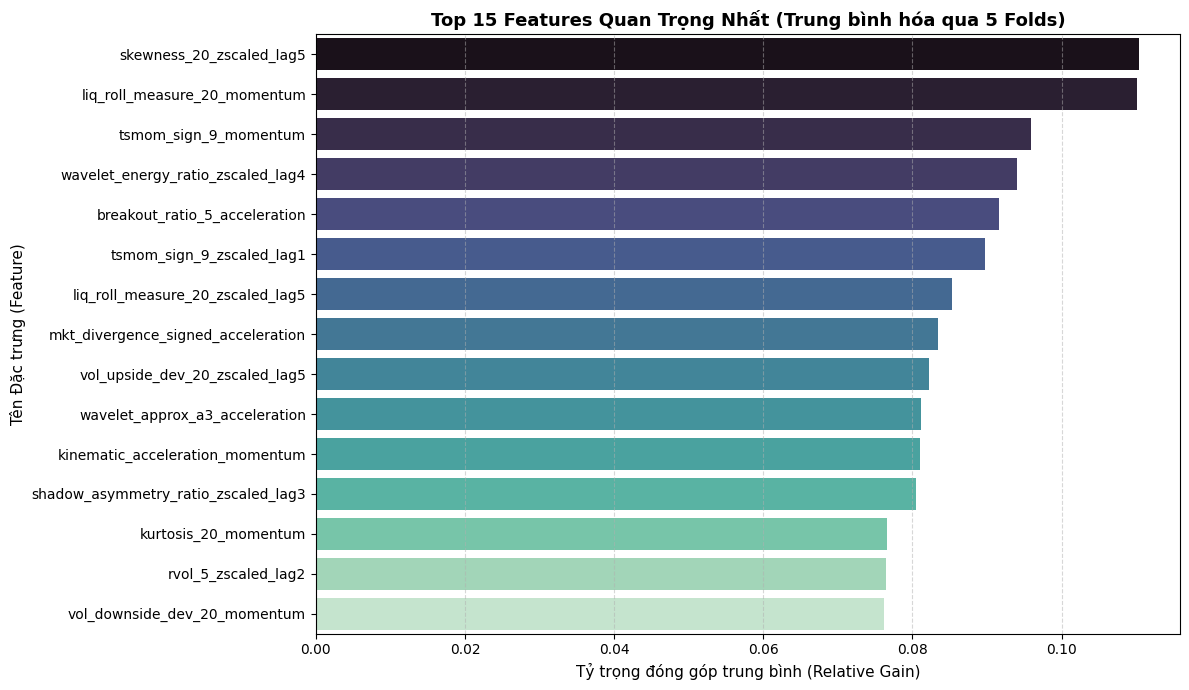

In [59]:
# =====================================================================
# 1. MODEL INTERPRETABILITY (FEATURE IMPORTANCE THEO CHUẨN GAIN)
# =====================================================================
def analyze_feature_importance(trained_models, top_n=15):
    """
    Trích xuất, chuẩn hóa và tổng hợp Feature Importance (Gain)
    từ danh sách mô hình (tương thích cả XGBClassifier lẫn CalibratedClassifierCV).
    """
    if not trained_models:
        print("[!] Cảnh báo: Danh sách trained_models đang rỗng.")
        return

    print("\n" + "=" * 80)
    print("PHÂN TÍCH TẦM QUAN TRỌNG ĐẶC TRƯNG (FEATURE IMPORTANCE DIAGNOSIS)")
    print("=" * 80)

    importance_records = []

    for fold_idx, model in enumerate(trained_models):
        # 1. Tự động bóc tách base estimator nếu bị bọc bởi CalibratedClassifierCV
        actual_model = model
        if hasattr(model, 'calibrated_classifiers_') and len(model.calibrated_classifiers_) > 0:
            actual_model = model.calibrated_classifiers_[0].estimator
        elif hasattr(model, 'estimator'):
            actual_model = model.estimator

        # 2. Trích xuất Gain score từ Booster
        if hasattr(actual_model, 'get_booster'):
            booster = actual_model.get_booster()
            score_gain = booster.get_score(importance_type='gain')
        elif hasattr(actual_model, 'feature_importances_'):
            # Fallback nếu feature_names có sẵn
            f_names = getattr(actual_model, 'feature_names_in_', [f'f_{i}' for i in range(len(actual_model.feature_importances_))])
            score_gain = dict(zip(f_names, actual_model.feature_importances_))
        else:
            print(f"[!] Không nhận diện được cấu trúc mô hình ở Fold {fold_idx + 1}. Bỏ qua.")
            continue

        total_gain = sum(score_gain.values()) if score_gain else 1.0

        for f_name, gain in score_gain.items():
            importance_records.append({
                'Fold': f'Fold_{fold_idx + 1}',
                'Feature': f_name,
                'Gain': gain,
                'Relative_Importance': gain / total_gain
            })

    df_imp = pd.DataFrame(importance_records)

    if df_imp.empty:
        print("[!] Không thể trích xuất feature importance.")
        return None

    # 3. Tổng hợp và tính toán độ ổn định qua các fold
    summary_imp = df_imp.groupby('Feature').agg(
        Mean_Importance=('Relative_Importance', 'mean'),
        Std_Importance=('Relative_Importance', 'std'),
        Fold_Count=('Fold', 'nunique')
    ).reset_index()

    summary_imp['Std_Importance'] = summary_imp['Std_Importance'].fillna(0.0)
    summary_imp = summary_imp.sort_values(by='Mean_Importance', ascending=False).reset_index(drop=True)

    # Hiển thị Top N
    print(f"\n[Top {top_n} Đặc trưng đóng góp Gain cao nhất]")
    try:
        print(summary_imp.head(top_n).to_markdown(index=False))
    except ImportError:
        print(summary_imp.head(top_n).to_string(index=False))

    # Trực quan hóa
    plt.figure(figsize=(12, 7))
    top_features = summary_imp.head(top_n)
    sns.barplot(
        data=top_features,
        x='Mean_Importance',
        y='Feature',
        palette='mako'
    )
    plt.title(f'Top {top_n} Features Quan Trọng Nhất (Trung bình hóa qua {len(trained_models)} Folds)', fontsize=13, fontweight='bold')
    plt.xlabel('Tỷ trọng đóng góp trung bình (Relative Gain)', fontsize=11)
    plt.ylabel('Tên Đặc trưng (Feature)', fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return summary_imp

df_feature_metrics = analyze_feature_importance(trained_models, top_n=15)

## Visualization


TÍNH TOÁN VÀ VẼ ĐƯỜNG CONG VỐN OUT-OF-SAMPLE (OOS EQUITY)


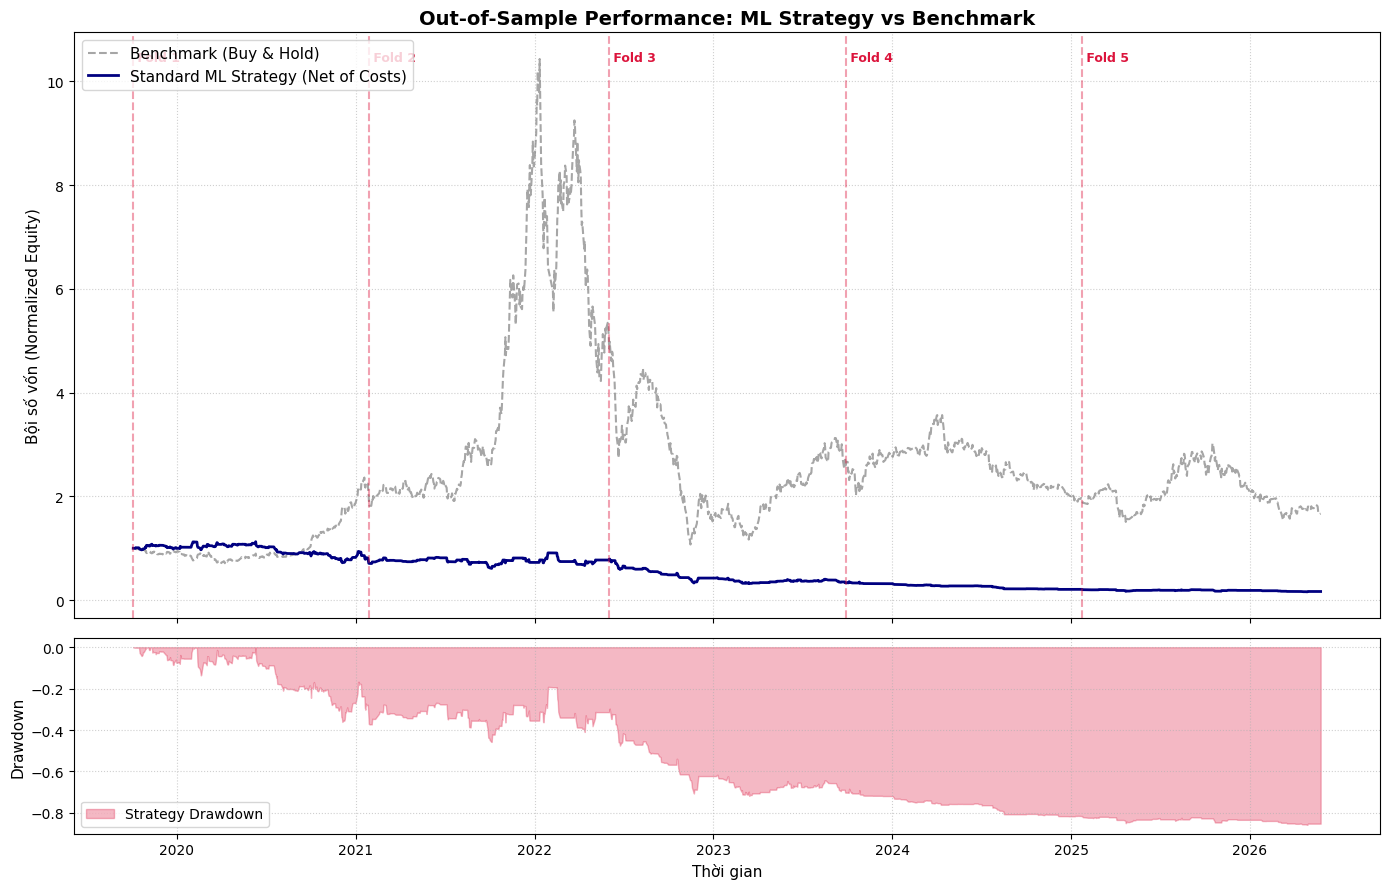

In [60]:
# =====================================================================
# 2. VISUALIZATION (EQUITY CURVE & DRAWDOWN THEO CHUẨN TURNOVER)
# =====================================================================
def plot_oos_performance(oos_predictions, raw_df, base_fee_bps=15, slippage_bps=5):
    """
    Mô phỏng đường cong vốn OOS thực tế:
    - Đồng bộ chính xác tên cột 'model_raw_target'
    - Thực thi trễ T+1 (Lag-1 Execution)
    - Tính phí dựa trên biến động vị thế thực (Turnover)
    """
    print("\n" + "=" * 80)
    print("TÍNH TOÁN VÀ VẼ ĐƯỜNG CONG VỐN OUT-OF-SAMPLE (OOS EQUITY)")
    print("=" * 80)

    # 1. Đồng bộ dữ liệu
    perf_df = oos_predictions[['fold', 'model_raw_target']].copy()

    # Kiểm tra biến giá
    if 'target_barrier_return' in raw_df.columns:
        # Sử dụng return 1 phiên (thay vì multi-day horizon) để tính daily mark-to-market
        perf_df = perf_df.join(raw_df[['close']], how='inner')
        perf_df['asset_return'] = perf_df['close'].pct_change().fillna(0.0)
    elif 'log_return' in raw_df.columns:
        perf_df = perf_df.join(raw_df[['log_return']], how='inner')
        perf_df['asset_return'] = np.exp(perf_df['log_return']) - 1.0
    else:
        raise KeyError("raw_df cần có cột 'close' hoặc 'log_return'.")

    # 2. Loại trừ Lookahead: Tín hiệu hôm nay chỉ khớp tại giá đóng cửa/mở cửa hôm sau
    perf_df['position'] = perf_df['model_raw_target'].shift(1).fillna(0.0)

    # 3. Tính Turnover thực tế (Từ -1 sang +1 = 2 đơn vị giao dịch)
    perf_df['turnover'] = perf_df['position'].diff().abs().fillna(0.0)
    total_cost_rate = (base_fee_bps + slippage_bps) / 10000.0  # 20 bps = 0.0020
    perf_df['costs'] = perf_df['turnover'] * total_cost_rate

    # 4. Lợi nhuận chiến lược hàng ngày
    perf_df['strat_net_return'] = (perf_df['position'] * perf_df['asset_return']) - perf_df['costs']

    # 5. Đường cong tăng trưởng vốn (Bắt đầu từ mốc 1.0)
    perf_df['Equity_Strategy'] = (1.0 + perf_df['strat_net_return']).cumprod()
    perf_df['Equity_Benchmark'] = (1.0 + perf_df['asset_return']).cumprod()

    # 6. Tính toán Drawdown
    rolling_max = perf_df['Equity_Strategy'].cummax()
    perf_df['Drawdown'] = (perf_df['Equity_Strategy'] - rolling_max) / rolling_max

    # 7. Trực quan hóa kết hợp 2 tầng (Equity Curve + Drawdown)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Tầng 1: Equity
    ax1.plot(perf_df.index, perf_df['Equity_Benchmark'], label='Benchmark (Buy & Hold)', color='gray', linestyle='--', alpha=0.7)
    ax1.plot(perf_df.index, perf_df['Equity_Strategy'], label='Standard ML Strategy (Net of Costs)', color='navy', linewidth=2)
    ax1.set_title('Out-of-Sample Performance: ML Strategy vs Benchmark', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Bội số vốn (Normalized Equity)', fontsize=11)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Đánh dấu ranh giới các Folds
    fold_changes = perf_df.drop_duplicates(subset=['fold'], keep='first')
    for idx_row, row in fold_changes.iterrows():
        ax1.axvline(x=idx_row, color='crimson', linestyle='--', alpha=0.4)
        ax1.text(idx_row, ax1.get_ylim()[1] * 0.95, f" Fold {int(row['fold'])}", color='crimson', fontsize=9, fontweight='bold')

    # Tầng 2: Drawdown
    ax2.fill_between(perf_df.index, perf_df['Drawdown'], 0, color='crimson', alpha=0.3, label='Strategy Drawdown')
    ax2.set_ylabel('Drawdown', fontsize=11)
    ax2.set_xlabel('Thời gian', fontsize=11)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='lower left', fontsize=10)

    plt.tight_layout()
    plt.show()

    return perf_df

# Gọi hàm chạy trực tiếp vẽ biểu đồ Equity Curve
df_perf_results = plot_oos_performance(
    oos_predictions=df_oos_calibrated,
    raw_df=df_final,
    base_fee_bps=15,
    slippage_bps=5
)